# Setup

In [ ]:
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
import os
import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models, optimizers
import keras_tuner as kt
import pickle
from tensorflow.keras.models import model_from_json
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation
import hashlib
from collections import defaultdict
from google.colab import files
from tensorflow.keras.models import load_model
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

2.18.0


In [ ]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# GPU details
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"TensorFlow using: {device_name}")
else:
    print("TensorFlow NOT using a GPU")

# test tensor
tensor = tf.random.uniform([3, 3])
print("Tensor is allocated on:", tensor.device)

TensorFlow Version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow using: /device:GPU:0
Tensor is allocated on: /job:localhost/replica:0/task:0/device:GPU:0


In [ ]:
!nvidia-smi

Sat Mar 22 10:14:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             46W /  400W |     427MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!wget https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz
print('----------------DONE-----------------')
!tar -xvzf imagenette2-160.tgz
print('----------------DONE-----------------')

Streaming output truncated to the last 5000 lines.
imagenette2-160/train/n03888257/n03888257_23339.JPEG
imagenette2-160/train/n03888257/n03888257_44204.JPEG
imagenette2-160/train/n03888257/n03888257_61633.JPEG
imagenette2-160/train/n03888257/n03888257_15067.JPEG
imagenette2-160/train/n03888257/n03888257_75365.JPEG
imagenette2-160/train/n03888257/n03888257_63966.JPEG
imagenette2-160/train/n03888257/n03888257_3927.JPEG
imagenette2-160/train/n03888257/n03888257_20684.JPEG
imagenette2-160/train/n03888257/ILSVRC2012_val_00047778.JPEG
imagenette2-160/train/n03888257/n03888257_14016.JPEG
imagenette2-160/train/n03888257/n03888257_37776.JPEG
imagenette2-160/train/n03888257/ILSVRC2012_val_00041706.JPEG
imagenette2-160/train/n03888257/n03888257_17513.JPEG
imagenette2-160/train/n03888257/n03888257_17143.JPEG
imagenette2-160/train/n03888257/n03888257_6738.JPEG
imagenette2-160/train/n03888257/n03888257_4355.JPEG
imagenette2-160/train/n03888257/ILSVRC2012_val_00030583.JPEG
imagenette2-160/train/n0388

In [ ]:
# Define dataset paths
dataset_path = "/content/imagenette2-160"
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")

In [ ]:
print(f"Train directory: {os.path.exists(train_dir)}")
print(f"Validation directory: {os.path.exists(val_dir)}")

Train directory: True
Validation directory: True


# Question 1

In [ ]:
# Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode="int",
    image_size=(160, 160),
    batch_size=32,
    shuffle=True
)

class_names = train_dataset.class_names

Found 9469 files belonging to 10 classes.


In [ ]:
# Load Full Validation Dataset
val_dataset_full = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode="int",
    image_size=(160, 160),
    batch_size=32,
    shuffle=False,
)

# Apply a fixed shuffle with seed and cache to keep order
val_dataset_full = val_dataset_full.shuffle(buffer_size=4000, seed=42, reshuffle_each_iteration=False)

Found 3925 files belonging to 10 classes.


### Checking for duplicates

In [ ]:
# Combine train and validation datasets
combined_dataset = train_dataset.concatenate(val_dataset_full)

In [ ]:
# Checking total count
total_samples = 0
for batch in combined_dataset:
    images, labels = batch
    total_samples += images.shape[0]

print(f"Totalt: {total_samples}")

Totalt: 13394


In [ ]:
def get_tensor_hash(image_tensor):

    image_array = image_tensor.numpy()
    image_bytes = image_array.tobytes()
    return hashlib.md5(image_bytes).hexdigest()

# map hashes to images
hash_dict = defaultdict(list)

for idx, (images, labels) in enumerate(combined_dataset):
    for i in range(images.shape[0]):
        image = images[i]
        hash_val = get_tensor_hash(image)
        hash_dict[hash_val].append((idx, i))


duplicates = {k: v for k, v in hash_dict.items() if len(v) > 1}

print(f"---{len(duplicates)} duplicate images---")

---0 duplicate images---


## Splitting

In [ ]:
# Get dataset sizes
train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
train_size = int(train_batches)

val_batches = tf.data.experimental.cardinality(val_dataset_full).numpy()
val_size = int(0.7 * val_batches)
test_size = val_batches - val_size

print(f"Number of training batches: {train_size}")
print(f"Number of val batches: {val_size}")
print(f"Number of test batches: {test_size}")

Number of training batches: 296
Number of val batches: 86
Number of test batches: 37


In [ ]:
# Split validation dataset into validation (70%) and test (30%)
val_dataset = val_dataset_full.take(val_size)
test_dataset = val_dataset_full.skip(val_size)

In [ ]:
print("Class Names:", class_names)

Class Names: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


In [ ]:
# Normalize pixel values [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
# dataset shapes
for images, labels in train_dataset.take(1):
    print(f"Train batch shape: {images.shape} ------------- Labels shape: {labels.shape}")
for images, labels in val_dataset.take(1):
    print(f"Validation batch shape: {images.shape} ------------- Labels shape: {labels.shape}")
for images, labels in test_dataset.take(1):
    print(f"Test batch shape: {images.shape} ------------- Labels shape: {labels.shape}")


Train batch shape: (32, 160, 160, 3) ------------- Labels shape: (32,)
Validation batch shape: (32, 160, 160, 3) ------------- Labels shape: (32,)
Test batch shape: (32, 160, 160, 3) ------------- Labels shape: (32,)


In [ ]:
# Function to count samples per class
def count_classes(dataset):
    class_counts = {}
    for _, labels in dataset:
        for label in labels.numpy():
            class_counts[label] = class_counts.get(label, 0) + 1
    return class_counts

# Count class distribution
train_counts = count_classes(train_dataset)
val_counts = count_classes(val_dataset)
test_counts = count_classes(test_dataset)

print("Train set class distribution:\n", train_counts)
print('\n')
print("Validation set class distribution:\n", val_counts)
print('\n')
print("Test set class distribution:\n", test_counts)


Train set class distribution:
 {np.int32(9): 960, np.int32(3): 858, np.int32(2): 993, np.int32(7): 931, np.int32(1): 955, np.int32(6): 961, np.int32(5): 956, np.int32(8): 951, np.int32(4): 941, np.int32(0): 963}


Validation set class distribution:
 {np.int32(0): 323, np.int32(2): 229, np.int32(5): 274, np.int32(9): 277, np.int32(8): 320, np.int32(7): 227, np.int32(1): 299, np.int32(6): 317, np.int32(4): 153, np.int32(3): 322}


Test set class distribution:
 {np.int32(4): 256, np.int32(7): 192, np.int32(8): 79, np.int32(2): 128, np.int32(3): 64, np.int32(5): 120, np.int32(6): 72, np.int32(0): 64, np.int32(1): 96, np.int32(9): 113}


In [ ]:
print('Validation lables for 1st batch')
for images, labels in val_dataset.take(1):
    print(images.shape)
    print(labels.numpy())

print('\n')
print('Test lables for 1st batch')
for images, labels in test_dataset.take(1):
    print(images.shape)
    print(labels.numpy())

Validation lables for 1st batch
(32, 160, 160, 3)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Test lables for 1st batch
(32, 160, 160, 3)
[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]


In [ ]:
# sample 1st Validtaion batch pixel values
for sample in val_dataset.take(1):
    print(sample)

(<tf.Tensor: shape=(32, 160, 160, 3), dtype=float32, numpy=
array([[[[5.89007378e-01, 7.78566241e-01, 6.05992675e-01],
         [5.48676550e-01, 7.03713238e-01, 5.74154437e-01],
         [6.68872595e-01, 7.72978008e-01, 6.93076015e-01],
         ...,
         [3.16176504e-01, 3.80269617e-01, 2.78308839e-01],
         [2.98088074e-01, 3.70649278e-01, 2.60796547e-01],
         [3.18970472e-01, 3.93480271e-01, 2.69289166e-01]],

        [[6.10392153e-01, 7.99951017e-01, 6.26078427e-01],
         [7.15355396e-01, 8.70392203e-01, 7.36887276e-01],
         [7.52389729e-01, 8.56495142e-01, 7.76593208e-01],
         ...,
         [3.70159328e-01, 4.28982854e-01, 3.45281869e-01],
         [2.94068843e-01, 3.58811349e-01, 2.62696296e-01],
         [3.25538814e-01, 3.89582992e-01, 2.84350187e-01]],

        [[7.45796621e-01, 9.27512288e-01, 7.49068677e-01],
         [6.64987743e-01, 8.18027020e-01, 6.74730420e-01],
         [6.55330896e-01, 7.60110319e-01, 6.71691239e-01],
         ...,
         

In [ ]:
# sample 1st Test batch pixel values
for sample in test_dataset.take(1):
    print(sample)

(<tf.Tensor: shape=(32, 160, 160, 3), dtype=float32, numpy=
array([[[[1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         ...,
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00]],

        [[1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         ...,
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00]],

        [[1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         [1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
         ...,
         

In [ ]:
# Function to plot images
def plot_images(dataset, num_images=9):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(num_images):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy())
            plt.axis("off")
    plt.show()

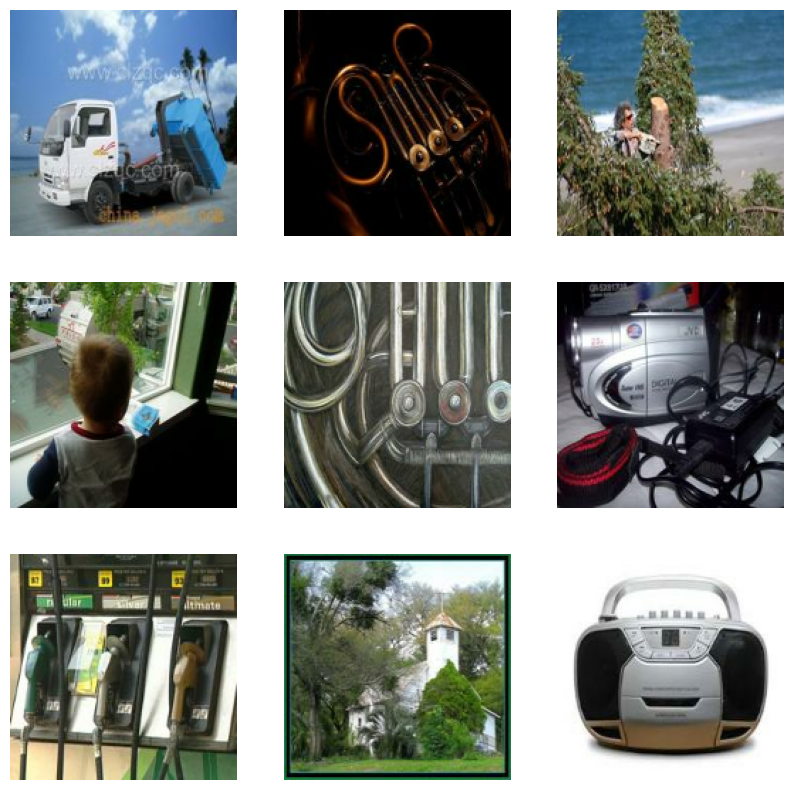

In [ ]:
# Display 9 sample images from the each dataset
plot_images(train_dataset)

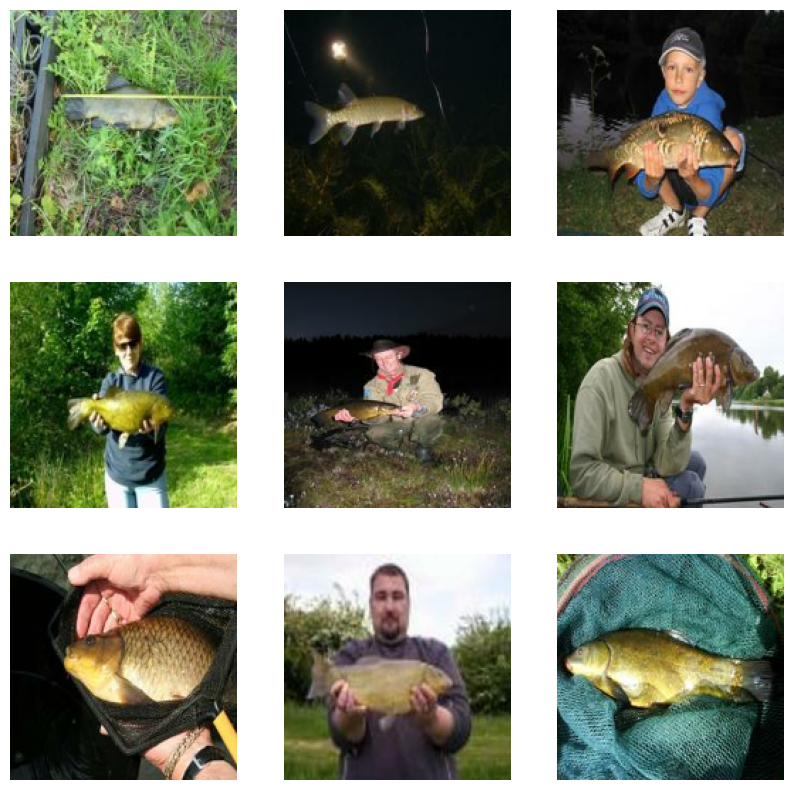

In [ ]:
plot_images(val_dataset)

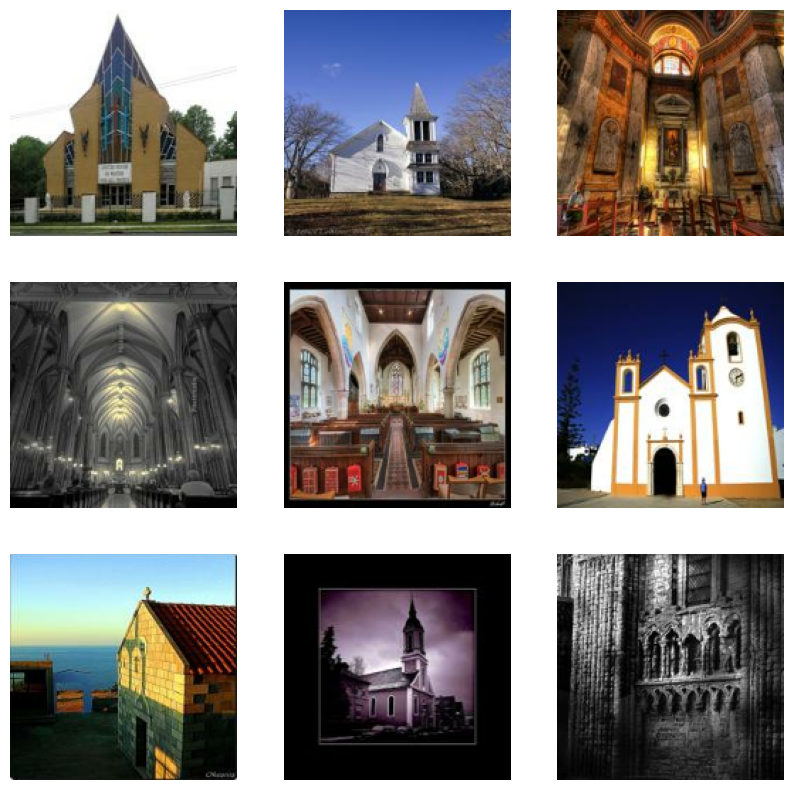

In [ ]:
plot_images(test_dataset)

In [ ]:
# function for plotting training,validtaion curves
def plot_training_history(history):

    plt.figure(figsize=(18, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training & Validation Accuracy')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training & Validation Loss')

    plt.show()

# Question 2

In [ ]:
mlp_model = models.Sequential([
    layers.Flatten(input_shape=(160, 160, 3)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


mlp_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


mlp_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 256)                 │      19,661,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,695,242 (75.13 MB)

 Trainable params: 19,695,242 (75.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = mlp_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1944 - loss: 11.1175 - val_accuracy: 0.2495 - val_loss: 2.9263
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2930 - loss: 2.4231 - val_accuracy: 0.3006 - val_loss: 2.2923
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3299 - loss: 2.1076 - val_accuracy: 0.3619 - val_loss: 1.9100
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3415 - loss: 1.9533 - val_accuracy: 0.3586 - val_loss: 1.8831
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3580 - loss: 1.8651 - val_accuracy: 0.3185 - val_loss: 2.0208
Epoch 6/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3833 - loss: 1.7942 - val_accuracy: 0.3776 - val_loss: 1.8757
Epoch 7/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4102 - loss: 1.7390 - val_accuracy: 0.2981 - val_loss: 2.1192
Epoch 8/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4087 - loss: 1.7294 - val_accuracy: 

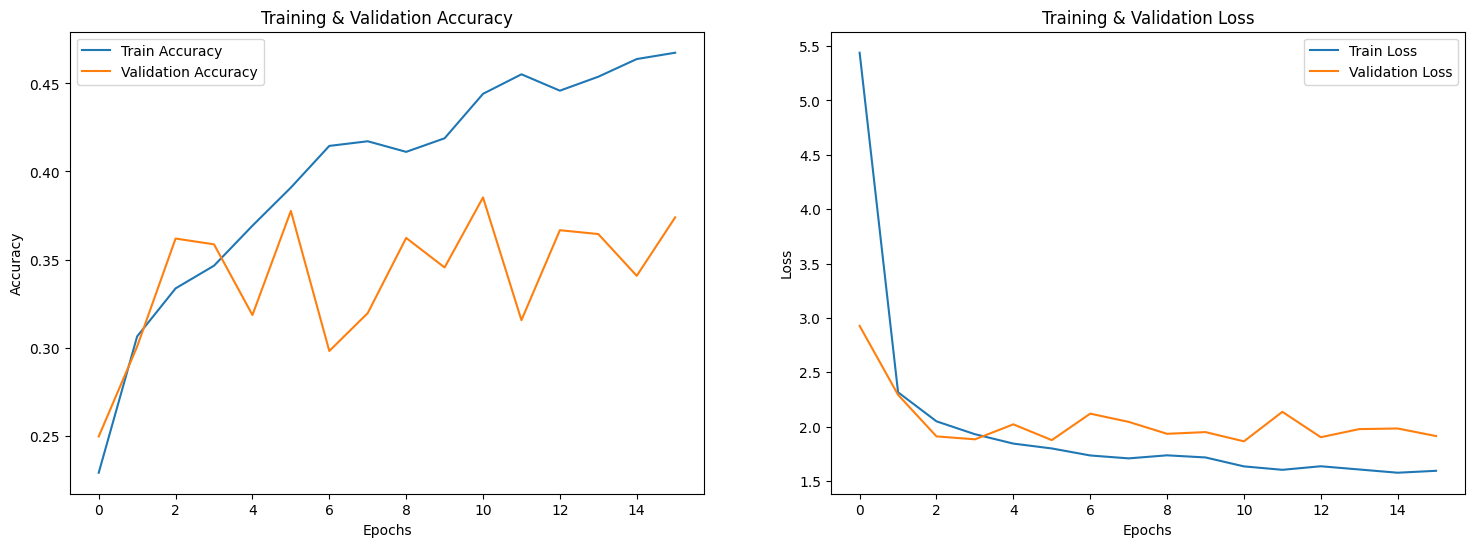

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = mlp_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3678 - loss: 1.8801
Test Loss: 1.8006
Test Accuracy: 0.4054


## Evaluation & Discussion:
- Loss: 1.8006
- Accuracy: 40.54%


- The training accuracy increases over epochs, reaching above 45%.
- The validation accuracy increases at the start and then fluctuates significantly.
- There is no clear plateau in validation accuracy
- The training loss decreases steadily indicating that the model is learning on the training set.
- The validation loss stops decreasing early and fluctuates instead of following the training loss trend.
  

- The model is overfitting because:
	- Training loss is continuously decreasing while validation loss stagnates and fluctuates.
	- Validation accuracy is not improving consistently
	- The gap between training and validation loss widens after a few epochs
	- Test accuracy is low, meaning poor generalization


- There might be mild underfitting because:
	- Training accuracy is relatively low (around 45%), meaning the model struggles even on training data.



In [ ]:
mlp_model.save("Q2_mlp_model.h5")
files.download("Q2_mlp_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
uploaded = files.upload()

Saving Q2_mlp_model.h5 to Q2_mlp_model.h5


In [ ]:
Q2_mlp_model = load_model("Q2_mlp_model.h5")

In [ ]:
# Print weights layer by layer
for layer in Q2_mlp_model.layers:
    print('\n')
    print(f"---------------------Layer: {layer.name}-----------------")
    for weight in layer.get_weights():
        print(weight)
    print(f"---------------------------------------------------------")



---------------------Layer: flatten_5-----------------
---------------------------------------------------------


---------------------Layer: dense_16-----------------
[[-1.1175491e-02 -1.9305579e-03  7.7810755e-04 ... -4.6164966e-03
  -1.1804874e-02 -4.9051411e-02]
 [-2.5501798e-03 -1.0431679e-02  1.7802138e-02 ...  1.8791240e-02
  -1.3486025e-02 -3.6151689e-02]
 [-1.6580581e-03 -1.0411849e-02 -2.2691386e-03 ...  5.4715425e-03
  -6.1141546e-03  3.8404015e-03]
 ...
 [-3.5547528e-03 -1.3896371e-02  1.1129711e-02 ...  4.7755763e-03
  -8.4220264e-03 -4.8943567e-03]
 [ 3.4372006e-03 -6.9701211e-03  1.1601044e-02 ... -2.9915164e-04
  -1.0850815e-02 -9.5100280e-05]
 [-6.1619435e-03 -8.3041508e-03  5.5822846e-03 ...  5.5306670e-03
  -6.6273906e-03  2.6748223e-02]]
[-5.0887149e-03 -5.9982021e-03 -8.4470594e-03 -6.0049435e-03
  3.5010147e-05 -3.9182152e-03 -6.0039819e-03 -2.9953641e-03
 -5.0207861e-03 -5.9936089e-03 -4.1731535e-03 -6.7698332e-03
 -1.6530290e-02 -6.0029146e-03 -6.9832072e-02 

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = Q2_mlp_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3678 - loss: 1.8801
Test Loss: 1.8006
Test Accuracy: 0.4054


# Question 3

## Model 1

In [ ]:
# Build MLP Model with One Hidden Layer (512 Neurons)
mlp_model_1 = models.Sequential([
    layers.Flatten(input_shape=(160, 160, 3)),
    layers.Dense(512, activation='relu'),  # Single hidden layer with 512 neurons
    layers.Dense(10, activation='softmax')
])

# Compile the model
mlp_model_1.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Model summary
mlp_model_1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)                  │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 512)                 │      39,322,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,327,242 (150.02 MB)

 Trainable params: 39,327,242 (150.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = mlp_model_1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.1914 - loss: 27.0601 - val_accuracy: 0.2638 - val_loss: 2.7905
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2612 - loss: 2.5984 - val_accuracy: 0.1656 - val_loss: 2.2427
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2172 - loss: 2.1406 - val_accuracy: 0.1977 - val_loss: 2.1888
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2476 - loss: 2.0920 - val_accuracy: 0.2576 - val_loss: 2.1472
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2812 - loss: 2.0355 - val_accuracy: 0.2495 - val_loss: 2.0767
Epoch 6/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2772 - loss: 2.0293 - val_accuracy: 0.2605 - val_loss: 2.0389
Epoch 7/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2702 - loss: 2.0062 - val_accuracy: 0.2601 - val_loss: 2.1210
Epoch 8/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2955 - loss: 1.9671 - val_accuracy: 

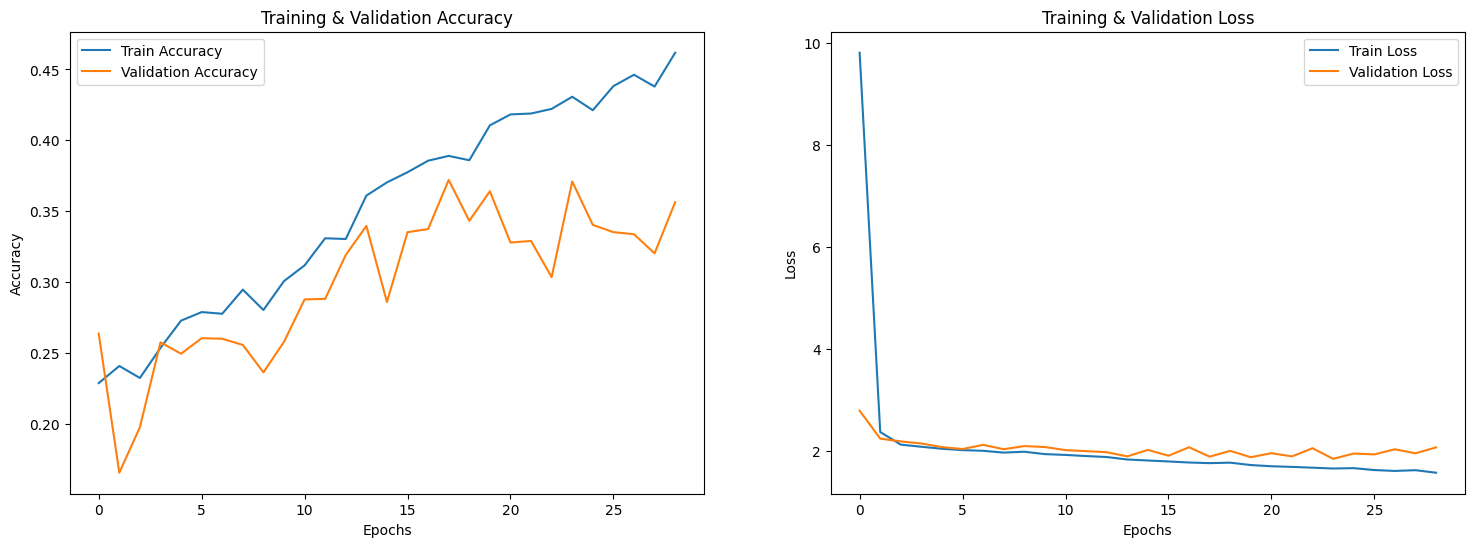

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = mlp_model_1.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3327 - loss: 1.9046
Test Loss: 1.8472
Test Accuracy: 0.3818


### MLP Model 1
- Reducing the model to one hidden layer with 512 neurons led to a slight drop in test accuracy (40.54% to 38.18%)
- There was also an increase in test loss (1.8006 to 1.8472), indicating a decline in performance.
- The new model struggles more with generalization as validation accuracy remains unstable and overfitting still occurs.
- The original two-layer MLP model in question 2 performed better.
- This means that deeper architectures help extract more meaningful features in image classification tasks.

## Model 2

In [ ]:
# Build MLP Model with Three Hidden Layers (512 → 256 → 128 Neurons)
mlp_model_2 = models.Sequential([
    layers.Flatten(input_shape=(160, 160, 3)),
    layers.Dense(512, activation='relu'),  # First hidden layer (512 neurons)
    layers.Dense(256, activation='relu'),  # Second hidden layer (256 neurons)
    layers.Dense(128, activation='relu'),  # Third hidden layer (128 neurons)
    layers.Dense(10, activation='softmax')
])

# Compile the model
mlp_model_2.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Model summary
mlp_model_2.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)                  │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 512)                 │      39,322,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,487,626 (150.63 MB)

 Trainable params: 39,487,626 (150.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = mlp_model_2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.1795 - loss: 10.9643 - val_accuracy: 0.2495 - val_loss: 2.2598
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3048 - loss: 2.1153 - val_accuracy: 0.2893 - val_loss: 2.0830
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3556 - loss: 1.9318 - val_accuracy: 0.3659 - val_loss: 1.8605
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3677 - loss: 1.8621 - val_accuracy: 0.3473 - val_loss: 1.8939
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3775 - loss: 1.8097 - val_accuracy: 0.3561 - val_loss: 1.9283
Epoch 6/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3997 - loss: 1.7694 - val_accuracy: 0.3517 - val_loss: 1.9378
Epoch 7/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4042 - loss: 1.7649 - val_accuracy: 0.3995 - val_loss: 1.8151
Epoch 8/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4326 - loss: 1.6600 - val_accuracy: 

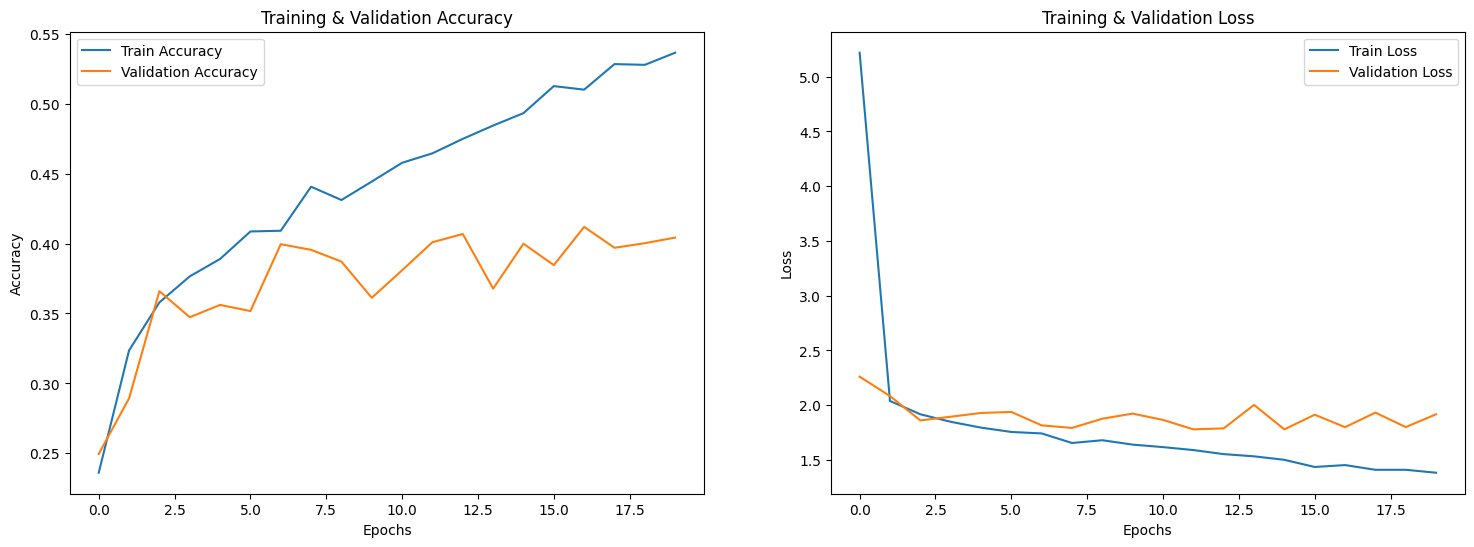

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = mlp_model_2.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4273 - loss: 1.7767
Test Loss: 1.7636
Test Accuracy: 0.4274


### MLP Model 2
- Expanding the model to three hidden layers (512, 256, 128) improved test accuracy (38.18% to 42.74%)
- The test loss also reduced (1.8472 to 1.7636), indicating better feature extraction and learning.
- The validation accuracy is more stable, suggesting improved generalization
- There is still some overfitting.
- Compared to model 1, this deeper architecture performs better, showing that adding more layers helps extract complex patterns in image data

## Model 3

In [ ]:
# Build MLP Model with Four Hidden Layers (1024 → 512 → 256 → 128 Neurons)
mlp_model_3 = models.Sequential([
    layers.Flatten(input_shape=(160, 160, 3)),
    layers.Dense(1024, activation='relu'),  # First hidden layer (1024 neurons)
    layers.Dense(512, activation='relu'),  # Second hidden layer (512 neurons)
    layers.Dense(256, activation='relu'),  # Third hidden layer (256 neurons)
    layers.Dense(128, activation='relu'),  # Fourth hidden layer (128 neurons)
    layers.Dense(10, activation='softmax')
])

# Compile the model
mlp_model_3.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Model summary
mlp_model_3.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)                 │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 1024)                │      78,644,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,334,538 (302.64 MB)

 Trainable params: 79,334,538 (302.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = mlp_model_3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.1585 - loss: 13.2702 - val_accuracy: 0.2900 - val_loss: 2.2595
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3023 - loss: 1.9956 - val_accuracy: 0.3291 - val_loss: 1.9447
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3472 - loss: 1.9091 - val_accuracy: 0.3397 - val_loss: 1.9066
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3683 - loss: 1.8382 - val_accuracy: 0.3484 - val_loss: 1.9002
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3942 - loss: 1.7635 - val_accuracy: 0.3827 - val_loss: 1.8034
Epoch 6/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4076 - loss: 1.7253 - val_accuracy: 0.3776 - val_loss: 1.8591
Epoch 7/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4091 - loss: 1.7282 - val_accuracy: 0.3856 - val_loss: 1.7914
Epoch 8/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4170 - loss: 1.6887 - val_accuracy:

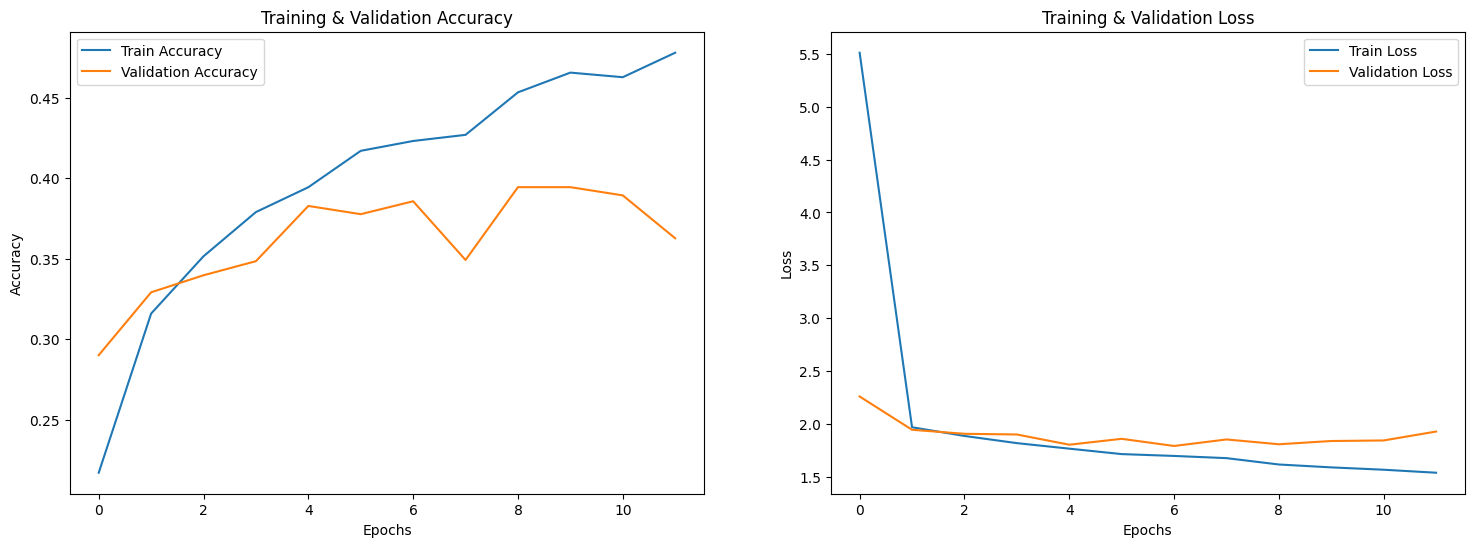

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = mlp_model_3.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3548 - loss: 1.8871
Test Loss: 1.7845
Test Accuracy: 0.4037


### Model 3
- Expanding to four hidden layers (1024, 512, 256, 128) slightly decreased test accuracy (42.74% to 40.37%) and increased test loss (1.7636 to 1.7845).  
- The model might be overfitting due to excessive complexity.
- Compared to the previous three-layer model, this model does not generalize as well.
- This means that adding layers doesnt always boost performance.
- There must be an optimal number of layers.

-----------> **Choose Model 2's architecture since it has the highest test accuacry and lowest test loss**

## Learning rate scheduling

## Model 4

- initial_learning_rate = 0.01
- decay_steps = steps_per_epoch * 1
- decay_rate = 0.9

In [ ]:
# Caculating steps_per_epoch
train_samples = len(train_dataset) * 32
steps_per_epoch = train_samples // 32
print(steps_per_epoch)

296


In [ ]:
# Build MLP Model with Three Hidden Layers (512 → 256 → 128 Neurons)
mlp_model_4 = models.Sequential([
    layers.Flatten(input_shape=(160, 160, 3)),
    layers.Dense(512, activation='relu'),  # First hidden layer (512 neurons)
    layers.Dense(256, activation='relu'),  # Second hidden layer (256 neurons)
    layers.Dense(128, activation='relu'),  # Third hidden layer (128 neurons)
    layers.Dense(10, activation='softmax')
])


# Exponential Decay learning rate schedule
initial_learning_rate = 0.01
decay_steps = steps_per_epoch * 1
decay_rate = 0.9

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


# Compile the model

mlp_model_4.compile(optimizer=optimizer,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Model summary
mlp_model_4.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)                 │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 512)                 │      39,322,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,487,626 (150.63 MB)

 Trainable params: 39,487,626 (150.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# log learning rate
class LearningRateLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(tf.cast(epoch + 1, tf.float32)).numpy()
        else:
            lr = lr.numpy()

        self.lrs.append(lr)
        print(f"\nEpoch {epoch+1}: Learning Rate = {lr:.6f}\n")

In [ ]:
# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lr_logger = LearningRateLogger()

In [ ]:
history = mlp_model_4.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_logger]
)

Epoch 1/30
291/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3785 - loss: 1.7756
Epoch 1: Learning Rate = 0.000382

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3785 - loss: 1.7754 - val_accuracy: 0.3262 - val_loss: 1.9219
Epoch 2/30
291/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3802 - loss: 1.7660
Epoch 2: Learning Rate = 0.000343

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3803 - loss: 1.7659 - val_accuracy: 0.3240 - val_loss: 1.9220
Epoch 3/30
286/296 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3787 - loss: 1.7674
Epoch 3: Learning Rate = 0.000309

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3789 - loss: 1.7671 - val_accuracy: 0.3207 - val_loss: 1.9205
Epoch 4/30
293/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3831 - loss: 1.7588
Epoch 4: Learning Rate = 0.000278

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3832 - loss: 1.7587 - val_accuracy: 0.3225 - val_loss: 1.9200
Epoch 5/30
286/296 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

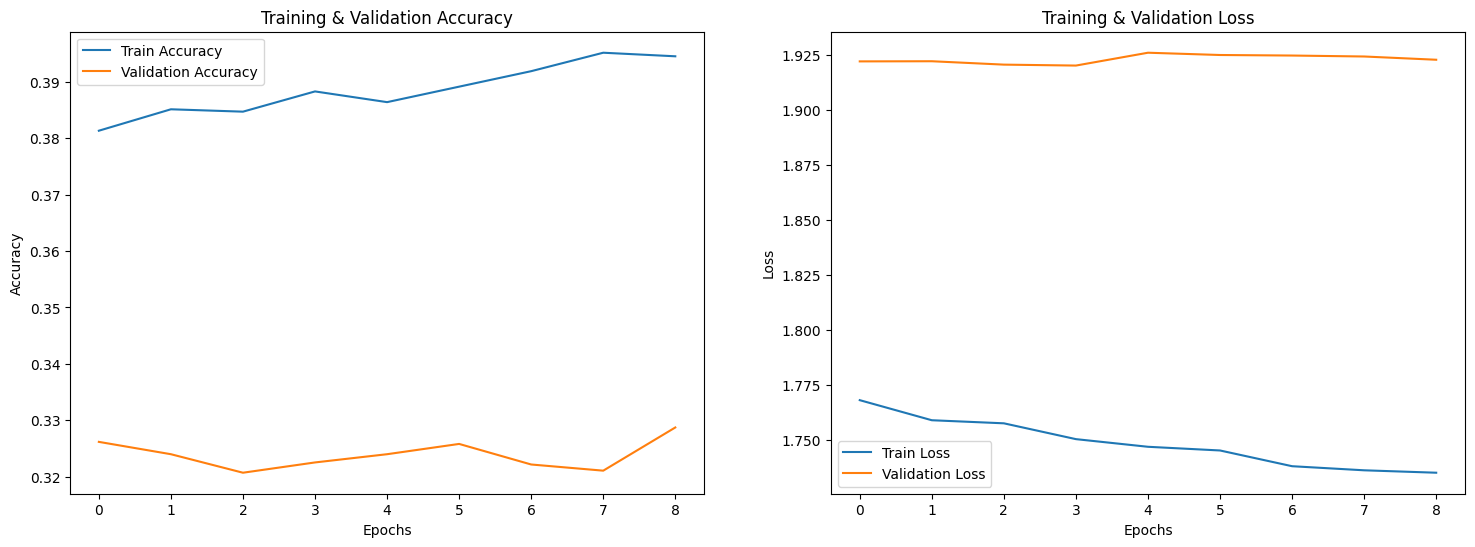

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = mlp_model_4.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2844 - loss: 1.9420
Test Loss: 1.8813
Test Accuracy: 0.3412


### Model 4
- Applying learning rate scheduling worsened performance.
- It reduced test accuracy (42.74% to 34.12%) and increased test loss (1.7636 to 1.8813).
- The training and validation accuracy curves show that the model struggled to converge properly.
- This could be due to an aggressive decay rate.  
- Generalization has worsened meaning that fine-tuning the learning rate decay parameters must be done

## Model 5

*Modification*
- Lower Initial Learning Rate to 0.005
- Increase decay rate to 0.95
- Decay every 5 epochs instead

In [ ]:
# Build MLP Model
mlp_model_5 = models.Sequential([
    layers.Flatten(input_shape=(160, 160, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


# Exponential Decay learning rate schedule
initial_learning_rate = 0.005
decay_steps = steps_per_epoch * 5
decay_rate = 0.95

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


# Compile the model

mlp_model_5.compile(optimizer=optimizer,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Model summary
mlp_model_5.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)                 │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 512)                 │      39,322,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,487,626 (150.63 MB)

 Trainable params: 39,487,626 (150.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lr_logger = LearningRateLogger()

# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history = mlp_model_5.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_logger]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1587 - loss: 58.8404
Epoch 1: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1589 - loss: 58.6975 - val_accuracy: 0.2579 - val_loss: 2.0907
Epoch 2/30
291/296 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2745 - loss: 2.0518
Epoch 2: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2747 - loss: 2.0515 - val_accuracy: 0.2638 - val_loss: 2.1035
Epoch 3/30
289/296 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3063 - loss: 1.9602
Epoch 3: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3066 - loss: 1.9599 - val_accuracy: 0.3152 - val_loss: 1.9581
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3317 - loss: 1.9368
Epoch 4: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3317 - loss: 1.9368 - val_accuracy: 0.2733 - val_loss: 2.0617
Epoch 5/30
292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 4m

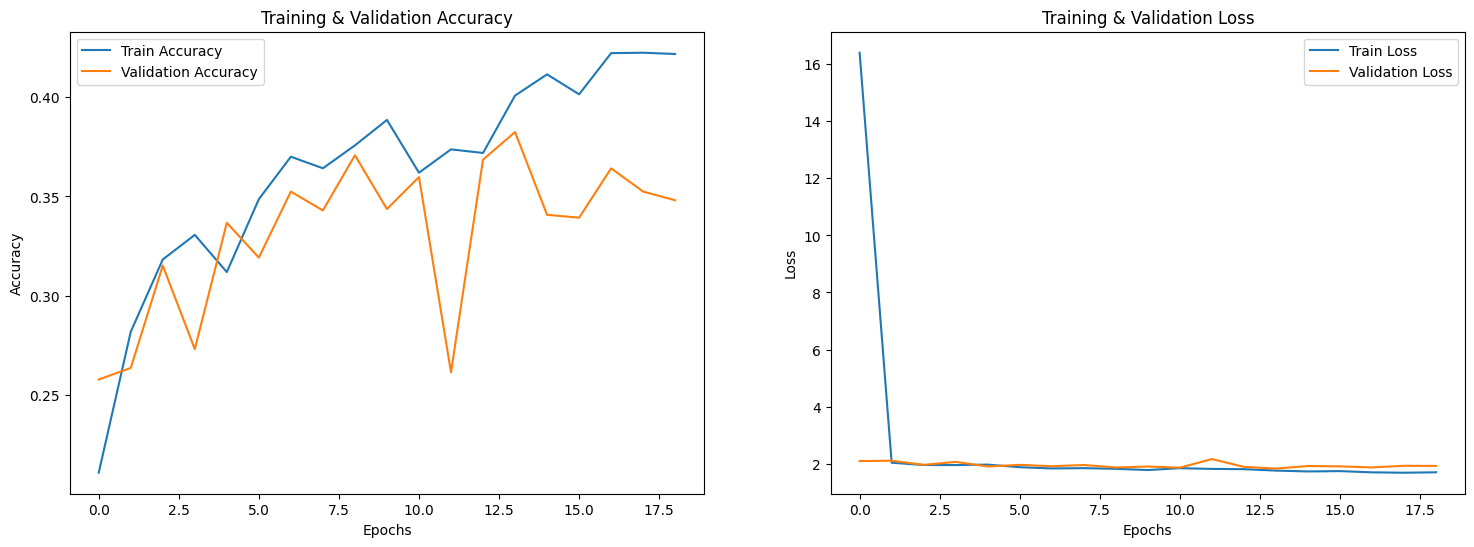

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = mlp_model_5.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3723 - loss: 1.8302
Test Loss: 1.7707
Test Accuracy: 0.4012


### Model 5
- Reducing the initial learning rate  and adjusting the decay rate improved test accuracy (34.12% to 40.12%) and lowered test loss (1.8813 to 1.7707).
- This indicates better learning stability.
- The smoother training and validation curves suggest that the model is learning more effectively with reduced fluctuations.
- Compared to the previous model, generalization has improved, showing that fine-tuning the learning rate and decay schedule helps with performance.

## Batch Normalisation and Dropout

## Model 6

--- > **Continue with Model 5's setting for now**

- add Batch normalization after dense layers
- add dropout rate = 0.3

In [ ]:
# Build MLP Model
mlp_model_6 = models.Sequential([
    layers.Flatten(input_shape=(160, 160, 3)),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

# Exponential Decay learning rate schedule
initial_learning_rate = 0.005
decay_steps = steps_per_epoch * 5
decay_rate = 0.95

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


# Compile the model
mlp_model_6.compile(optimizer=optimizer,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Model summary
mlp_model_6.summary()

Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_46 (Flatten)                 │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_177 (Dense)                    │ (None, 512)                 │      39,322,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_140              │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_77 (Activation)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_98 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_178 (Dense)                    │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_141              │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_78 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_99 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_179 (Dense)                    │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_142              │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_79 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_100 (Dropout)                │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_180 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,491,210 (150.65 MB)

 Trainable params: 39,489,418 (150.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Learning Rate Logger
lr_logger = LearningRateLogger()

# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# Train Model
history = mlp_model_6.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_logger]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2415 - loss: 2.2134
Epoch 1: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.2416 - loss: 2.2130 - val_accuracy: 0.3262 - val_loss: 1.9278
Epoch 2/30
286/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3398 - loss: 1.9010
Epoch 2: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3403 - loss: 1.8998 - val_accuracy: 0.3608 - val_loss: 1.8146
Epoch 3/30
287/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3740 - loss: 1.7895
Epoch 3: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3743 - loss: 1.7889 - val_accuracy: 0.4039 - val_loss: 1.7401
Epoch 4/30
285/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4098 - loss: 1.7168
Epoch 4: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4100 - loss: 1.7162 - val_accuracy: 0.3871 - val_loss: 1.7894
Epoch 5/30
290/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

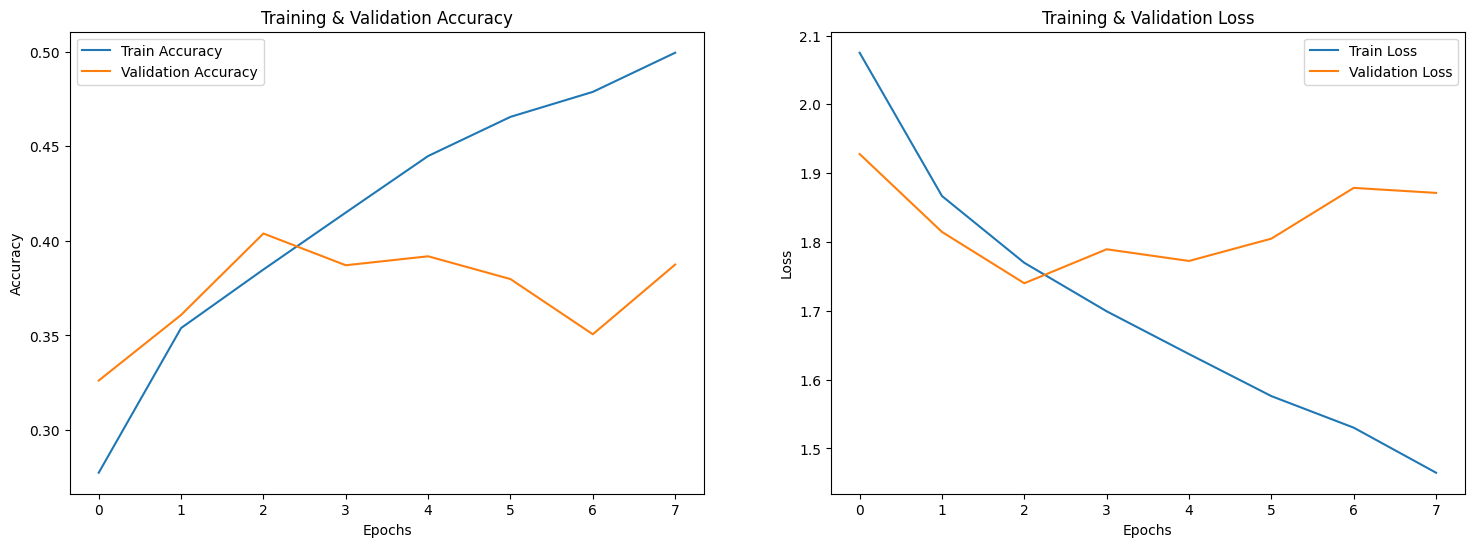

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = mlp_model_6.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4337 - loss: 1.6805
Test Loss: 1.6510
Test Accuracy: 0.4409


### Model 6
- Adding Batch Normalization and dropout improved test accuracy (40.12% to 44.09%) and reduced test loss (1.7707 to 1.6510).
- This indicates better learning and generalization.
- Batch normalization stabilized training, while dropout reduced overfitting.
- This led to a more reliable validation performance.
- Compared to the previous model, generalization has improved, showing that Batch Normalization and dropout helped to optimize training while preventing excessive memorization.
- There is still some overfitting (big differnece between final training accuracy and final validation accuracy) which can be improved on

## Model 7

- increase drop out rate to 0.4 for more generalization and less overfitting


In [ ]:
# Build MLP Model
mlp_model_7 = models.Sequential([
    layers.Flatten(input_shape=(160, 160, 3)),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

# Exponential Decay learning rate schedule
initial_learning_rate = 0.005
decay_steps = steps_per_epoch * 5
decay_rate = 0.95

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


# Compile the model
mlp_model_7.compile(optimizer=optimizer,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Model summary
mlp_model_7.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_18 (Flatten)                 │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 512)                 │      39,322,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,491,210 (150.65 MB)

 Trainable params: 39,489,418 (150.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Learning Rate Logger
lr_logger = LearningRateLogger()

# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# Train Model
history = mlp_model_7.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_logger]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2407 - loss: 2.2400
Epoch 1: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.2408 - loss: 2.2395 - val_accuracy: 0.3375 - val_loss: 1.9089
Epoch 2/30
287/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3267 - loss: 1.9145
Epoch 2: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3271 - loss: 1.9136 - val_accuracy: 0.3699 - val_loss: 1.8131
Epoch 3/30
287/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3603 - loss: 1.8340
Epoch 3: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3607 - loss: 1.8335 - val_accuracy: 0.3955 - val_loss: 1.7620
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3920 - loss: 1.7717
Epoch 4: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3920 - loss: 1.7717 - val_accuracy: 0.3834 - val_loss: 1.7793
Epoch 5/30
292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

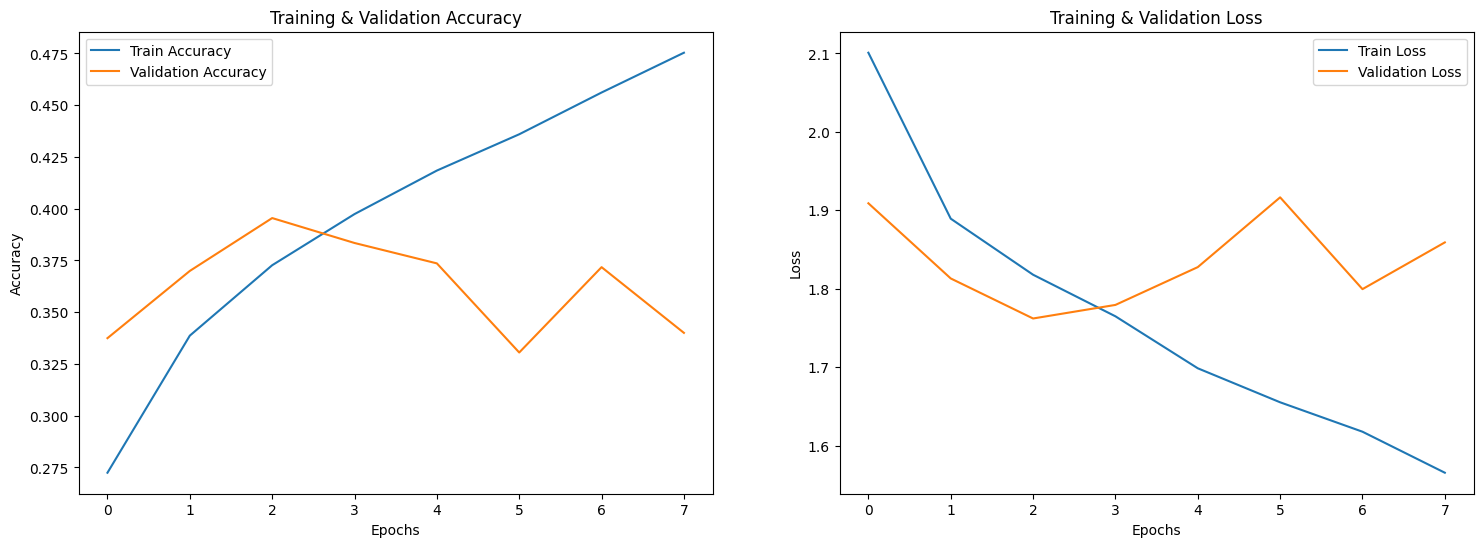

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = mlp_model_7.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4234 - loss: 1.7139
Test Loss: 1.6867
Test Accuracy: 0.4265


### Model 7
- Increasing the dropout rate to 0.4 slightly decreased test accuracy (44.09% to 42.65%) and increased test loss (1.6510 to 1.6867)
- This means that the model may have started underfitting.
- The validation accuracy is more unstable, indicating that the higher dropout may be reducing the model's capacity to learn meaningful patterns.
- Compared to the previous model, generalization has slightly worsened, implying that a dropout rate of 0.3 was better for balancing regularization and learning

---> **decrease drop out rate back to 0.3 (back to Model 6 settings)**



## BEST Model for Q3

- The best model so far is Model 6

In [ ]:
# Clone model architecture
best_modal_q3 = tf.keras.models.clone_model(mlp_model_6)

# Copy weights
best_modal_q3.set_weights(mlp_model_6.get_weights())

In [ ]:
# Exponential Decay learning rate schedule
initial_learning_rate = 0.005
decay_steps = steps_per_epoch * 5
decay_rate = 0.95

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


# Compile the model
best_modal_q3.compile(optimizer=optimizer,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

In [ ]:
# Evaluate test accuracy JUST TO CONFIRM
test_loss, test_acc = best_modal_q3.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4337 - loss: 1.6805
Test Loss: 1.6510
Test Accuracy: 0.4409


#### Save the best model for Q3

In [ ]:
best_modal_q3.save("Q3_mlp_model.h5")
files.download("Q3_mlp_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Reuploading the file to test

In [ ]:
uploaded = files.upload()

Saving Q3_mlp_model.h5 to Q3_mlp_model.h5


In [ ]:
best_modal_q3 = load_model("Q3_mlp_model.h5")

In [ ]:
# Print weights layer by layer
for layer in best_modal_q3.layers:
    print('\n')
    print(f"---------------------Layer: {layer.name}-----------------")
    for weight in layer.get_weights():
        print(weight)
    print(f"---------------------------------------------------------")



---------------------Layer: flatten_32-----------------
---------------------------------------------------------


---------------------Layer: dense_114-----------------
[[-0.03521017 -0.07349747 -0.06189348 ... -0.2166893   0.06449607
  -0.0355071 ]
 [-0.03532166 -0.09246945 -0.11114184 ...  0.06558961  0.03973587
  -0.03542902]
 [-0.02652561 -0.0125939  -0.45507088 ...  0.06552842  0.03296603
  -0.02626463]
 ...
 [ 0.02570767  0.02175858  0.01820073 ... -0.03749764  0.05063818
  -0.0398193 ]
 [ 0.02330057  0.01299643  0.0240293  ... -0.035257    0.03315212
  -0.03657919]
 [-0.054482    0.02425102  0.00352734 ...  0.00327918  0.0320591
  -0.02399673]]
[-1.54963303e-07 -1.75474324e-05 -1.76977010e-05 -1.83124212e-05
 -3.67700522e-05  7.09940923e-06  1.02101112e-05  1.49282332e-05
  3.46804809e-05 -2.37386994e-05  1.92923744e-06  4.46495578e-05
  1.56784499e-05  1.34215006e-05  5.62321338e-06 -3.24309804e-05
  6.14248438e-06  8.22064794e-06  6.18336435e-06  9.93989579e-06
  3.4704320

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = best_modal_q3.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4337 - loss: 1.6805
Test Loss: 1.6510
Test Accuracy: 0.4409


- The best model achieved 44.09% accuracy.
- The three-layer architecture (512, 256, 128) provided strong feature extraction without excessive overfitting.
- Early stopping led to stable generalization and well-tuned learning efficiency
- The exponential learning rate decay ensured smooth convergence by gradually lowering the learning rate, avoiding instability.
- The balanced regularization (Batch Normalization and Dropout 0.3) stabilized training and prevented overfitting.

# QUestion 4

## CNN Model 1

  --------------**I will start with the following architecure** -----------

- 4 convolutional layers with increasing filters (32 → 64 → 128 → 256)
  - Lower layers (32, 64 filters) will capture edges and textures.
  - Higher layers (128, 256 filters) will capture complex shapes and objects.
- Fully Connected Layer with 512 neerons
- Output layer (10 neurons, softmax activation)
- Activation Function	ReLU for non-linearity
- Kernel Size	3x3 for feature extraction
- Pooling Layer with	MaxPooling(2x2) to reduce spatial dimensions
- Batch Normalization to stabilize training
- Dropout (0.5 in Fully Connected layer) to prevent overfitting
- Loss Function	Sparse Categorical Crossentropy
- padding="same" was used in all Conv layers
    -	To ensure the output size is the same as the input size before pooling.
    -	To prevent excessive loss of spatial information, which is helpful for feature extraction.

- stride of (1,1)
  -	to ensure detailed feature extraction at each pixel location.

- To stabilize training and improve accuracy:
  - Use Learning Rate Scheduling (ReduceLROnPlateau)
  - Enable Early Stopping to prevent overfitting
 - Use Adam Optimizer with an initial learning rate of 0.001



In [ ]:
# Build CNN Model
def create_cnn():
    model = models.Sequential()

    # Convolutional Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", input_shape=(160, 160, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 4
    model.add(layers.Conv2D(256, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Flatten Layer
    model.add(layers.Flatten())

    # Fully Connected Layer
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(0.5))

    # Output Layer
    model.add(layers.Dense(10, activation="softmax"))

    return model

In [ ]:
# Create the CNN model
cnn_mode_1 = create_cnn()

# Compile the model
cnn_mode_1.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Print model summary
cnn_mode_1.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)                   │ (None, 160, 160, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_93               │ (None, 160, 160, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_20 (ReLU)                      │ (None, 160, 160, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 80, 80, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 80, 80, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_94               │ (None, 80, 80, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_21 (ReLU)                      │ (None, 80, 80, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 40, 40, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 40, 40, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_95               │ (None, 40, 40, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_22 (ReLU)                      │ (None, 40, 40, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 20, 20, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_96               │ (None, 20, 20, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_23 (ReLU)                      │ (None, 20, 20, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_43 (Flatten)                 │ (None, 25600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_155 (Dense)                    │ (None, 512)                 │      13,107,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_97               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │              

 Total params: 13,505,226 (51.52 MB)

 Trainable params: 13,503,242 (51.51 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
# Define Callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6)

In [ ]:
# Train the model
history = cnn_mode_1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.4147 - loss: 1.9347 - val_accuracy: 0.2609 - val_loss: 3.0720 - learning_rate: 0.0010
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6456 - loss: 1.0777 - val_accuracy: 0.5290 - val_loss: 1.5469 - learning_rate: 0.0010
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7291 - loss: 0.8228 - val_accuracy: 0.5961 - val_loss: 1.3775 - learning_rate: 0.0010
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7786 - loss: 0.6548 - val_accuracy: 0.6647 - val_loss: 1.0727 - learning_rate: 0.0010
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8256 - loss: 0.5263 - val_accuracy: 0.6676 - val_loss: 1.1713 - learning_rate: 0.0010
Epoch 6/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8741 - loss: 0.3891 - val_accuracy: 0.6633 - val_loss: 1.1923 - learning_rate: 0.0010
Epoch 7/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9029 - loss: 0

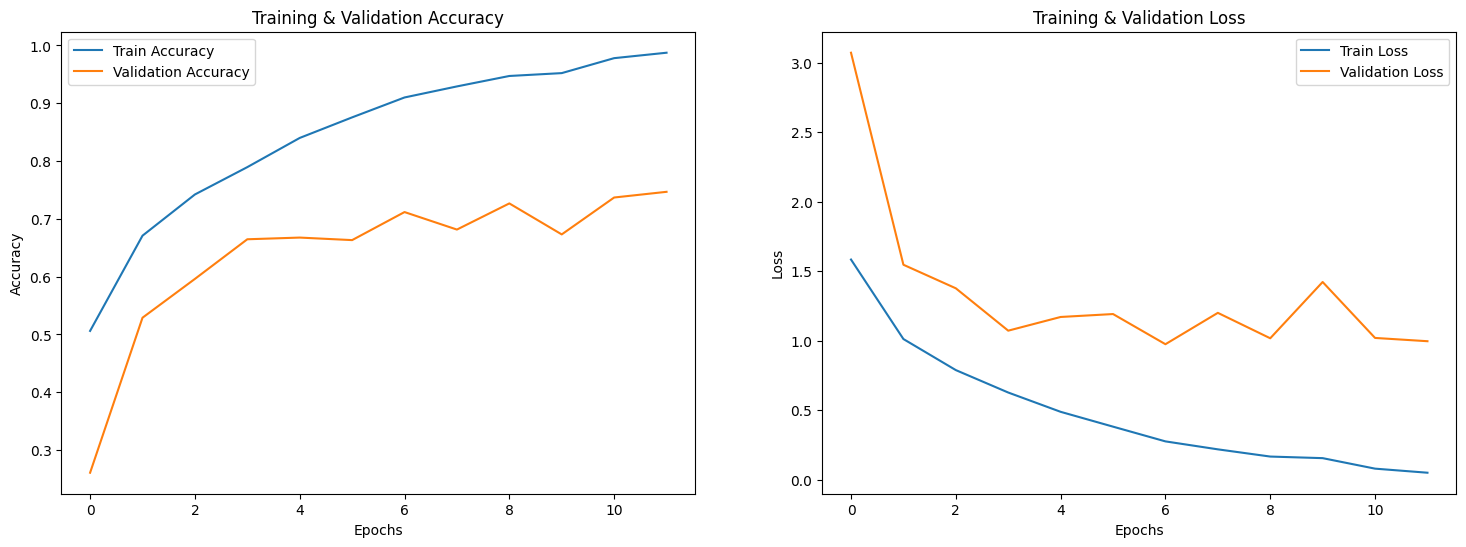

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = cnn_mode_1.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7197 - loss: 0.9682
Test Loss: 0.8997
Test Accuracy: 0.7441


- The model achieved 74.41% accuracy, demonstrating strong learning capability.
- However, the training accuracy is near 100%, while validation accuracy is significantly lower, indicating overfitting.
- The model benefits from the 4 Conv layers (with increasing number of filters) as it extracted features from the images.
- Batch normalization, dropout, adam optimizer and early stopping ensure stable training and adaptive learning.
- However, validation loss fluctuates which means generalization can be improved.

## CNN Model 2

- Deeper CNNs capture more complex patterns in image classification
- Hence, i will increase model complexity by adding 1 more Conv Layer
- A 5th convolutional block with 512 filters will be added


- Flattening creates too many parameters which can lead to overfitting.
- I will use Global Average Pooling instead  of flattening layer

In [ ]:
# Build CNN Model
def create_cnn():
    model = models.Sequential()

    # Convolutional Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", input_shape=(160, 160, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 4
    model.add(layers.Conv2D(256, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 5
    model.add(layers.Conv2D(512, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))


    # Global Average Pooling
    model.add(layers.GlobalAveragePooling2D())


    # Fully Connected Layer
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(0.5))

    # Output Layer
    model.add(layers.Dense(10, activation="softmax"))

    return model

In [ ]:
# Create the CNN model
cnn_mode_2 = create_cnn()

# Compile the model
cnn_mode_2.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Print model summary
cnn_mode_2.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)                   │ (None, 160, 160, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_98               │ (None, 160, 160, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_25 (ReLU)                      │ (None, 160, 160, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 80, 80, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 80, 80, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_99               │ (None, 80, 80, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_26 (ReLU)                      │ (None, 80, 80, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 40, 40, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 40, 40, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_100              │ (None, 40, 40, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_27 (ReLU)                      │ (None, 40, 40, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 20, 20, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_101              │ (None, 20, 20, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_28 (ReLU)                      │ (None, 20, 20, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 10, 10, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_102              │ (None, 10, 10, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_29 (ReLU)                      │ (None, 10, 10, 512)         │              

 Total params: 1,842,378 (7.03 MB)

 Trainable params: 1,839,370 (7.02 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [ ]:
# Define Callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6)

In [ ]:
# Train the model
history = cnn_mode_2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.3404 - loss: 2.0682 - val_accuracy: 0.1937 - val_loss: 3.9375 - learning_rate: 0.0010
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5552 - loss: 1.3791 - val_accuracy: 0.3309 - val_loss: 3.1627 - learning_rate: 0.0010
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6376 - loss: 1.1336 - val_accuracy: 0.5232 - val_loss: 1.7935 - learning_rate: 0.0010
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6816 - loss: 0.9702 - val_accuracy: 0.4345 - val_loss: 2.2394 - learning_rate: 0.0010
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7218 - loss: 0.8534 - val_accuracy: 0.4819 - val_loss: 1.6652 - learning_rate: 0.0010
Epoch 6/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7524 - loss: 0.7674 - val_accuracy: 0.7162 - val_loss: 0.8592 - learning_rate: 0.0010
Epoch 7/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7741 - loss: 0

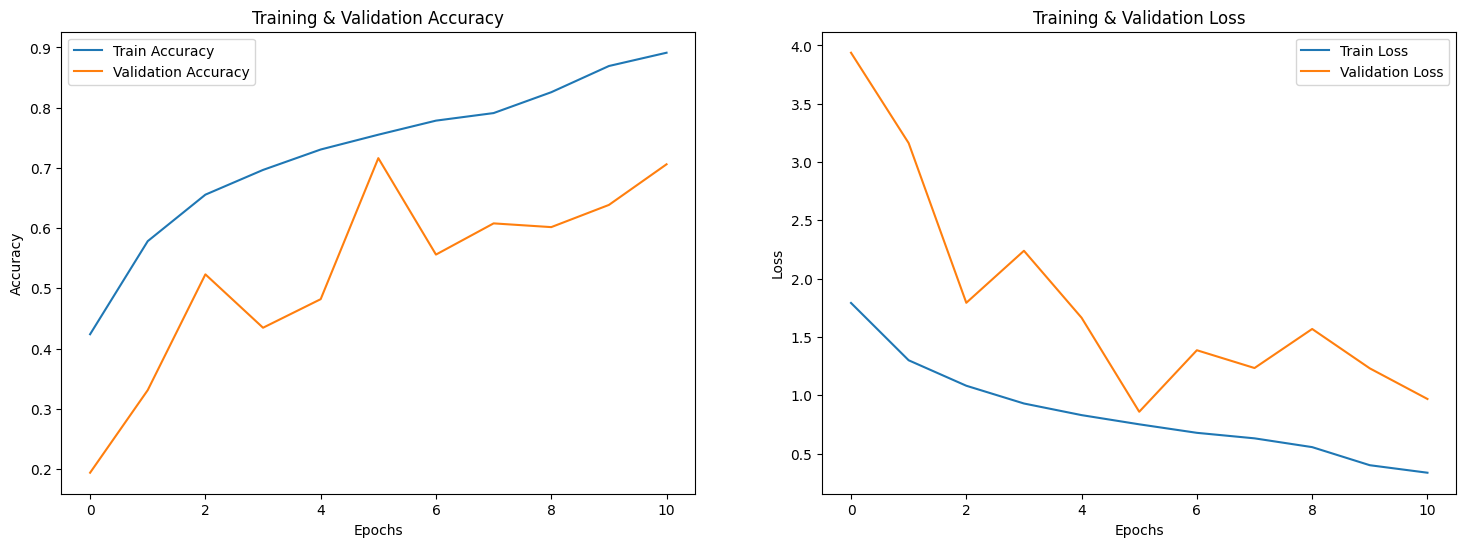

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = cnn_mode_2.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7347 - loss: 0.8538
Test Loss: 0.7810
Test Accuracy: 0.7500


- The model's test accuracy improved from 74.41% to 75.00%
- This could be due to the additional convolutional layer capturing more complex features.
- Test loss decreased (0.8997 to 0.7810), indicating better generalization and improved learning.
- Global Average Pooling reduced overfitting by lowering the parameter count, leading to a smoother validation loss curve.
- However, validation loss still fluctuates, suggesting the need for further fine-tuning.

## CNN Model 3

- Lower Learning Rate to 0.0005 for More Stable Training
- Use kernal size of (5,5) in later layers for high-level feature extraction


In [ ]:
# Build CNN Model
def create_cnn():
    model = models.Sequential()

    # Convolutional Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", input_shape=(160, 160, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 4
    model.add(layers.Conv2D(256, (5, 5), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 5
    model.add(layers.Conv2D(512, (5, 5), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))


    # Global Average Pooling
    model.add(layers.GlobalAveragePooling2D())


    # Fully Connected Layer
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(0.5))

    # Output Layer
    model.add(layers.Dense(10, activation="softmax"))

    return model

In [ ]:
# Create the CNN model
cnn_mode_3 = create_cnn()

# Compile the model
cnn_mode_3.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Print model summary
cnn_mode_3.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)                   │ (None, 160, 160, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_104              │ (None, 160, 160, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_31 (ReLU)                      │ (None, 160, 160, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 80, 80, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 80, 80, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_105              │ (None, 80, 80, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_32 (ReLU)                      │ (None, 80, 80, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 40, 40, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 40, 40, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_106              │ (None, 40, 40, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_33 (ReLU)                      │ (None, 40, 40, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 20, 20, 256)         │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_107              │ (None, 20, 20, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_34 (ReLU)                      │ (None, 20, 20, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 10, 10, 512)         │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_108              │ (None, 10, 10, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_35 (ReLU)                      │ (None, 10, 10, 512)         │              

 Total params: 4,463,818 (17.03 MB)

 Trainable params: 4,460,810 (17.02 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [ ]:
# Define Callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6)

In [ ]:
# Train the model
history = cnn_mode_3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.3460 - loss: 2.0344 - val_accuracy: 0.1613 - val_loss: 3.8131 - learning_rate: 5.0000e-04
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5686 - loss: 1.3269 - val_accuracy: 0.2455 - val_loss: 4.5686 - learning_rate: 5.0000e-04
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6516 - loss: 1.1001 - val_accuracy: 0.5662 - val_loss: 1.3833 - learning_rate: 5.0000e-04
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6970 - loss: 0.9422 - val_accuracy: 0.4517 - val_loss: 1.9217 - learning_rate: 5.0000e-04
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7298 - loss: 0.8186 - val_accuracy: 0.3907 - val_loss: 2.8899 - learning_rate: 5.0000e-04
Epoch 6/30
294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7540 - loss: 0.7378
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accurac

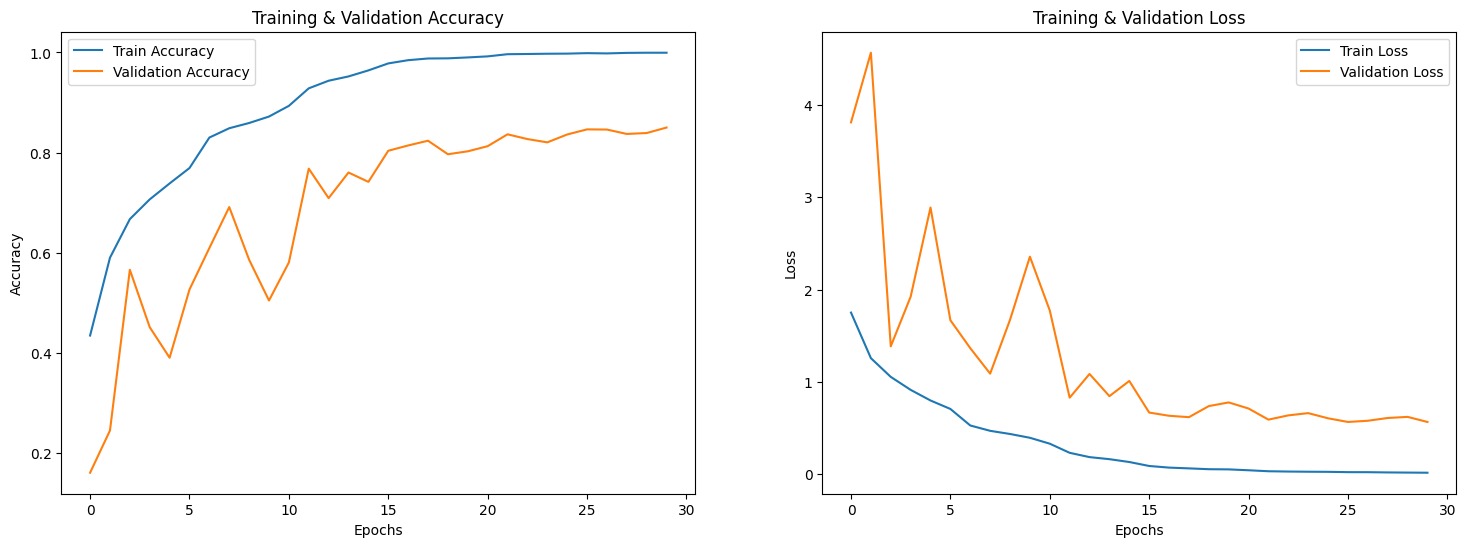

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = cnn_mode_3.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8327 - loss: 0.5931
Test Loss: 0.5364
Test Accuracy: 0.8438


- The model's performance improved alot, with test accuracy increasing from 75.00% to 84.38% and test loss decreasing from 0.7810 to 0.5364.
- Lowering the learning rate to 0.0005 contributed to more stable training and prevented sharp fluctuations in validation loss.
- Using (5,5) filters in later layers improved high-level feature extraction, helping the model capture more complex patterns and improve generalization.
- However, overfitting is still present as training accuracy is near 100%

## CNN Model 4

- The last 3 Cov layers (deeper conv layers) capture complex patterns
- Dropout can be applied here to prevent overfitting.
- Add Dropout (0.5) to last 3 Cov layers

In [ ]:
# Build CNN Model
def create_cnn():
    model = models.Sequential()

    # Convolutional Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", input_shape=(160, 160, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    # Convolutional Block 4
    model.add(layers.Conv2D(256, (5, 5), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    # Convolutional Block 5
    model.add(layers.Conv2D(512, (5, 5), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))


    # Global Average Pooling
    model.add(layers.GlobalAveragePooling2D())


    # Fully Connected Layer
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(0.5))

    # Output Layer
    model.add(layers.Dense(10, activation="softmax"))

    return model

In [ ]:
# Create the CNN model
cnn_mode_4 = create_cnn()

# Compile the model
cnn_mode_4.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Print model summary
cnn_mode_4.summary()


Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)                   │ (None, 160, 160, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_128              │ (None, 160, 160, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_55 (ReLU)                      │ (None, 160, 160, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_45 (MaxPooling2D)      │ (None, 80, 80, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_46 (Conv2D)                   │ (None, 80, 80, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_129              │ (None, 80, 80, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_56 (ReLU)                      │ (None, 80, 80, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_46 (MaxPooling2D)      │ (None, 40, 40, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_47 (Conv2D)                   │ (None, 40, 40, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_130              │ (None, 40, 40, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_57 (ReLU)                      │ (None, 40, 40, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_47 (MaxPooling2D)      │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_88 (Dropout)                 │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_48 (Conv2D)                   │ (None, 20, 20, 256)         │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_131              │ (None, 20, 20, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_58 (ReLU)                      │ (None, 20, 20, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_48 (MaxPooling2D)      │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_89 (Dropout)                 │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_49 (Conv2D)                   │ (None, 10, 10, 512)         │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,463,818 (17.03 MB)

 Trainable params: 4,460,810 (17.02 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [ ]:
# Define Callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6)

In [ ]:
# Train the model
history = cnn_mode_4.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.3111 - loss: 2.1518 - val_accuracy: 0.1824 - val_loss: 3.9147 - learning_rate: 5.0000e-04
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5251 - loss: 1.4439 - val_accuracy: 0.3648 - val_loss: 2.3984 - learning_rate: 5.0000e-04
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6031 - loss: 1.2426 - val_accuracy: 0.4367 - val_loss: 2.0089 - learning_rate: 5.0000e-04
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6575 - loss: 1.0582 - val_accuracy: 0.5804 - val_loss: 1.2957 - learning_rate: 5.0000e-04
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6805 - loss: 0.9887 - val_accuracy: 0.5943 - val_loss: 1.3464 - learning_rate: 5.0000e-04
Epoch 6/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7163 - loss: 0.8892 - val_accuracy: 0.6071 - val_loss: 1.2666 - learning_rate: 5.0000e-04
Epoch 7/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - ac

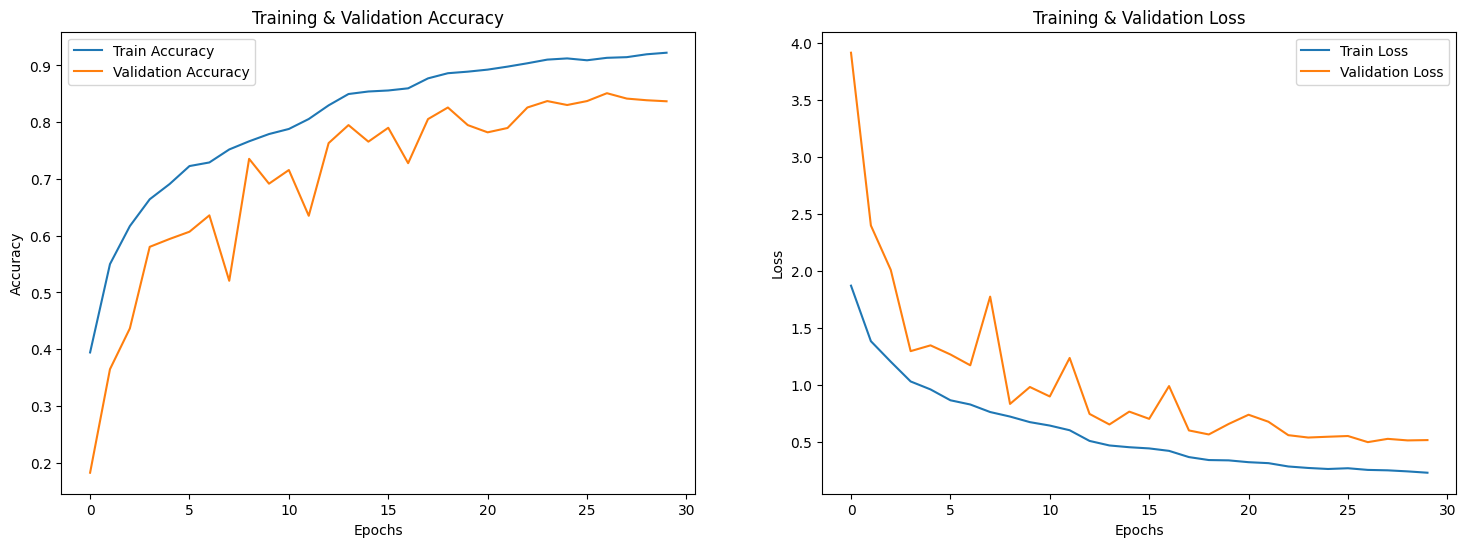

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = cnn_mode_4.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8307 - loss: 0.5412
Test Loss: 0.4903
Test Accuracy: 0.8454


- The Test Accuracy increased a bit from 84.38% to 84.54%
- Adding dropout in the last 3 Conv layers helped to reduce overfitting, improving model generalization.
- The reduced overfitting kept validation accuracy closer to training accuracy.
- The model now performs better on unseen data while maintaining high training accuracy.


- The test loss reduced from 0.5364 to 0.4903.
- This indicates improved stability in learning and better feature extraction.
- It also means the model is learning meaningful representations without excessive memorization.

- Validation loss fluctuations are reduced but slight instability still exists.

--- > **The best model so far is CNN Model 4**

In [ ]:
best_model_q4 = cnn_mode_4

In [ ]:
# Evaluate test accuracy JUST TO CONFIRM
test_loss, test_acc = best_model_q4.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8307 - loss: 0.5412
Test Loss: 0.4903
Test Accuracy: 0.8454


#### Save the best model for Q4

In [ ]:
best_model_q4.save("Q4_CNN_model.h5")
files.download("Q4_CNN_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Reuploading the file to test

In [ ]:
uploaded = files.upload()

Saving Q4_CNN_model.h5 to Q4_CNN_model.h5


In [ ]:
best_model_q4 = load_model("Q4_CNN_model.h5")

In [ ]:
# Print weights layer by layer
for layer in best_model_q4.layers:
    print('\n')
    print(f"---------------------Layer: {layer.name}-----------------")
    for weight in layer.get_weights():
        print(weight)
    print(f"---------------------------------------------------------")



---------------------Layer: conv2d_45-----------------
[[[[-9.07951444e-02 -2.90964786e-02 -1.25236005e-01  9.83912423e-02
     1.33046173e-02 -1.17676184e-01  8.76742005e-02 -7.18589872e-02
    -1.48006052e-01  2.21770480e-02  1.29569426e-01  7.21206740e-02
    -1.47581846e-02 -6.89603612e-02  7.36827105e-02  1.66831821e-01
    -9.04363692e-02 -4.32700478e-02 -1.13632847e-02  2.36342147e-01
    -1.53655410e-01  9.00159702e-02 -3.31785083e-02 -2.78606918e-02
     3.33265066e-02  1.33972257e-01 -5.72967343e-02 -3.03585976e-02
     4.19236124e-02 -2.52247304e-02 -6.52078018e-02 -1.17571317e-01]
   [-3.33011635e-02 -7.00077340e-02 -8.00807104e-02 -3.93083319e-03
    -1.85084175e-02  9.21620727e-02 -6.16484135e-03  1.66599393e-01
    -5.97087257e-02 -6.07673600e-02  3.49147953e-02  1.24229662e-01
     1.21107057e-01 -1.32113218e-01  1.46066239e-02 -1.95162632e-02
     2.54758578e-02 -4.37662862e-02 -2.67572515e-02  6.05355725e-02
     4.71244790e-02 -1.40485957e-01  2.15358697e-02 -2.003

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = best_model_q4.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8307 - loss: 0.5412
Test Loss: 0.4903
Test Accuracy: 0.8454


### Comparison of Best CNN Model with Best MLP Model
- The CNN model achieved 84.54% accuracy, outperforming the MLP model's 44.09% accuacy, due to its ability to extract spatial features.
- The CNN model also showed faster and more stable convergence, reaching high accuracy in fewer epochs, while the MLP model struggled with learning useful representations.
- The CNN model demonstrated better generalization, as its validation accuracy closely followed training accuracy, whereas the MLP model showed overfitting.
- Dropout in convolutional layers and global average pooling in CNN helped improve generalization.
- Overall, the CNN model's spatial feature extraction and architecture made it a better choice for image classification.

### Impact of different architectures and optimization techniques on performance
- For the CNN model:
	- The five convolutional layers effectively captured complex features, while the MaxPooling and dropout reduced overfitting and preserved relevant information.
	- Global Average Pooling improved generalization by lowering the parameter count

- For the MLP model:
	- It struggled with spatial feature extraction, as fully connected layers lacked the ability to preserve image structures.
	- Although the dropout and learning rate decay helped regularization, they were insufficient compared to the CNN model's spatial efficiency.

# Question 5

#### Reload the best model from Q3 and confirm the accuacy

In [ ]:
uploaded = files.upload()

Saving Q3_mlp_model.h5 to Q3_mlp_model (1).h5


In [ ]:
best_modal_q3 = load_model("Q3_mlp_model.h5")

In [ ]:
# Evaluate test accuracy JUST TO CONFIRM
test_loss, test_acc = best_modal_q3.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4337 - loss: 1.6805
Test Loss: 1.6510
Test Accuracy: 0.4409


## Confusion Matrix Analysis

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

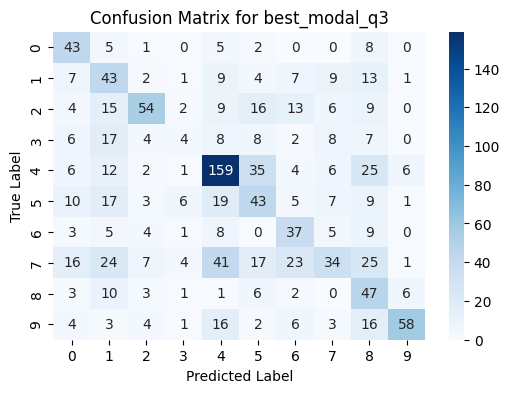

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.67      0.52        64
           1       0.28      0.45      0.35        96
           2       0.64      0.42      0.51       128
           3       0.19      0.06      0.09        64
           4       0.58      0.62      0.60       256
           5       0.32      0.36      0.34       120
           6       0.37      0.51      0.43        72
           7       0.44      0.18      0.25       192
           8       0.28      0.59      0.38        79
           9       0.79      0.51      0.62       113

    accuracy                           0.44      1184
   macro avg       0.43      0.44      0.41      1184
weighted avg       0.47      0.44      0.43      1184



In [ ]:
# Extract true labels and images from the test dataset
y_true = []
y_pred = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = best_modal_q3.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for best_modal_q3")
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred))


-Frequently Misclassified Classes:

- Classes 3 and 7 are  frequently misclassified
- Class 3 has a very low recall (0.06) and Class 7 also has low recall (0.18)
- Out of 64 TRUE Class 3 images, 60 of them were misclassifed
- Out of 192 TRUE Class 7 images, 158 of them were misclassifed

Most Common Misclassification Patterns:    
  - Many samples from class 1 are misclassified as class 8
  - Many samples from class 2 are misclassified as class 1,5 and 6
  - Many samples from class 3 are misclassified as class 1
  - Many samples from class 4 are misclassified as class 5 and 8
  - Many samples from class 5 are misclassified as class 1 and 4
  - Many samples from class 7 are misclassified as class 1,4,6 and 8
  - Many samples from class 8 are misclassified as class 4 and class 1
  - Many samples from class 9 are misclassified as class 4 and class 8

In [ ]:
cm

array([[ 43,   5,   1,   0,   5,   2,   0,   0,   8,   0],
       [  7,  43,   2,   1,   9,   4,   7,   9,  13,   1],
       [  4,  15,  54,   2,   9,  16,  13,   6,   9,   0],
       [  6,  17,   4,   4,   8,   8,   2,   8,   7,   0],
       [  6,  12,   2,   1, 159,  35,   4,   6,  25,   6],
       [ 10,  17,   3,   6,  19,  43,   5,   7,   9,   1],
       [  3,   5,   4,   1,   8,   0,  37,   5,   9,   0],
       [ 16,  24,   7,   4,  41,  17,  23,  34,  25,   1],
       [  3,  10,   3,   1,   1,   6,   2,   0,  47,   6],
       [  4,   3,   4,   1,  16,   2,   6,   3,  16,  58]])

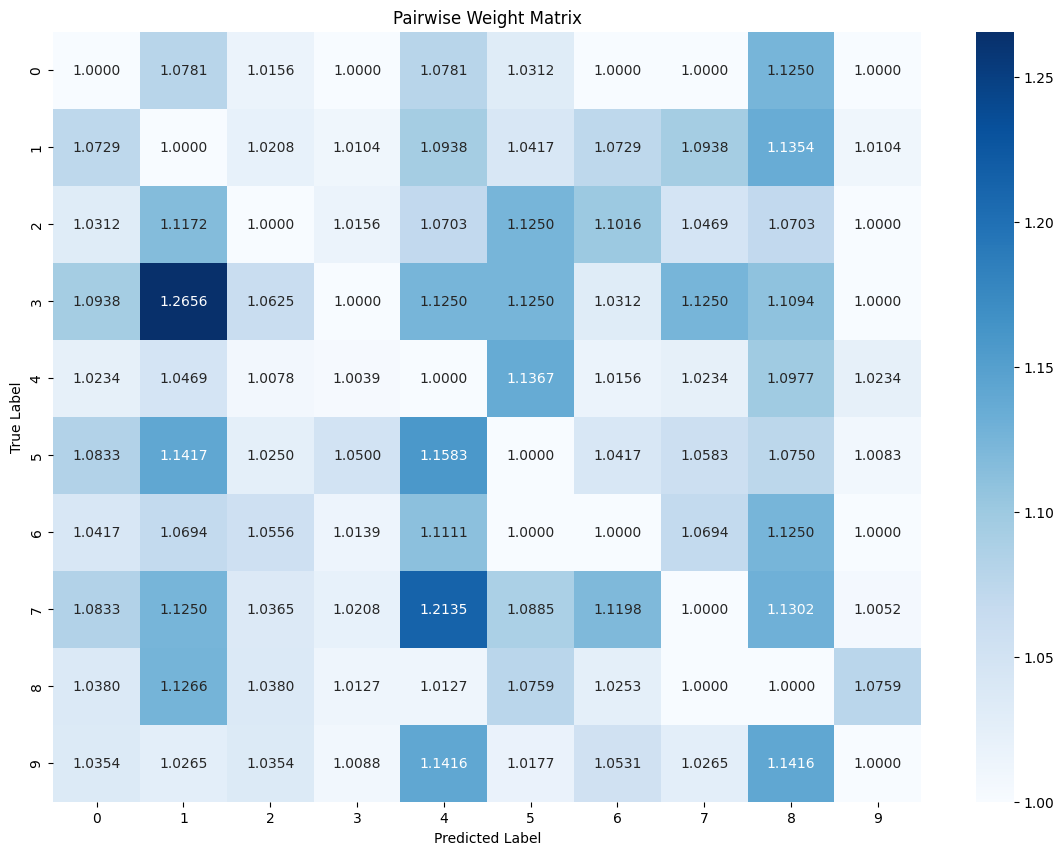

In [ ]:
conf_matrix = cm

# Compute Pairwise Weight Matrix
pairwise_weight_matrix = np.zeros_like(conf_matrix, dtype=float)

for i in range(conf_matrix.shape[0]):
    row_sum = np.sum(conf_matrix[i, :])
    for j in range(conf_matrix.shape[1]):
        if i == j:  # Correct classification
            pairwise_weight_matrix[i, j] = 1
        else:  # Misclassification
            pairwise_weight_matrix[i, j] = 1 + (conf_matrix[i, j] / row_sum)

# Plot the Pairwise Weight Matrix
plt.figure(figsize=(14,10))
sns.heatmap(pairwise_weight_matrix, annot=True, cmap="Blues", fmt=".4f")
plt.title("Pairwise Weight Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
# Convert pairwise weight matrix to TensorFlow tensor
pairwise_weight_matrix_tf = tf.convert_to_tensor(pairwise_weight_matrix, dtype=tf.float32)

# Custom Pairwise-Weighted Cross-Entropy Loss
def pairwise_weighted_loss(y_true, y_pred):


    y_true = tf.cast(y_true, tf.int32)

    # Compute standard sparse categorical cross-entropy loss
    ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

    # Compute predicted class indices
    y_pred_labels = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

    # Gather pairwise weights for (true_label, predicted_label) pairs
    batch_indices = tf.stack([y_true, y_pred_labels], axis=-1)
    weights = tf.gather_nd(pairwise_weight_matrix_tf, batch_indices)

    # Compute weighted loss
    weighted_loss = ce_loss * weights

    # Return mean weighted loss over batch
    return tf.reduce_mean(weighted_loss)


In [ ]:
# Clone model architecture
best_modal_q3_tuned = tf.keras.models.clone_model(best_modal_q3)

# Copy weights
best_modal_q3_tuned.set_weights(best_modal_q3.get_weights())

In [ ]:
# Exponential Decay learning rate schedule
initial_learning_rate = 0.005
decay_steps = steps_per_epoch * 5
decay_rate = 0.95

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


# Compile the model with the new loss function
best_modal_q3_tuned.compile(
    optimizer=optimizer,
    loss=pairwise_weighted_loss,  # New loss function
    metrics=['accuracy']
)

# Model summary
best_modal_q3_tuned.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_32 (Flatten)                 │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_114 (Dense)                    │ (None, 512)                 │      39,322,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_51               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_44 (Activation)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_47 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_115 (Dense)                    │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_52               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_45 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_48 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_116 (Dense)                    │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_53               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_46 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_117 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,491,210 (150.65 MB)

 Trainable params: 39,489,418 (150.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_logger = LearningRateLogger()

In [ ]:
# Continue Training (Fine-Tuning)
history = best_modal_q3_tuned.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_logger]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4425 - loss: 1.7478
Epoch 1: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.4425 - loss: 1.7478 - val_accuracy: 0.3003 - val_loss: 2.2571
Epoch 2/30
291/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4623 - loss: 1.6722
Epoch 2: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4623 - loss: 1.6723 - val_accuracy: 0.3335 - val_loss: 2.1355
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4975 - loss: 1.5798
Epoch 3: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4975 - loss: 1.5798 - val_accuracy: 0.3451 - val_loss: 2.1880
Epoch 4/30
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5086 - loss: 1.5168
Epoch 4: Learning Rate = 0.005000

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5086 - loss: 1.5169 - val_accuracy: 0.2926 - val_loss: 2.5818
Epoch 5/30
292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

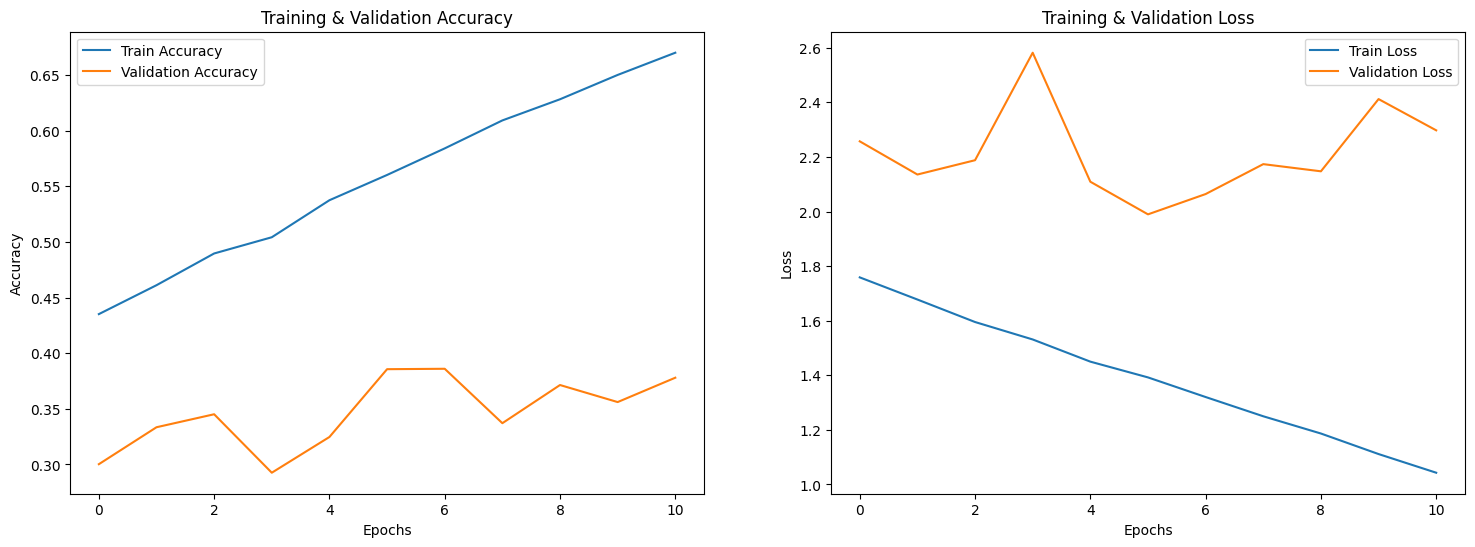

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = best_modal_q3_tuned.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4180 - loss: 1.8897
Test Loss: 1.9547
Test Accuracy: 0.4029


- The weights from the pairwise weight matrix may have a high variance, making some loss values disproportionately large.
- This could cause instability in weight updates.
- The loss function assigned different penalties to misclassifications, changing how the model prioritizes corrections.
- Frequently misclassified classes may be getting higher penalties, affecting optimization.

- The learning rate might be too high and the model might struggle to converge.
- A lower learning rate may be required when using a weighted loss as the dynamic weighting modifies the gradient magnitudes.

---> **Reduce initial_learning_rate to 0.0005**

In [ ]:
# Clone model architecture
modal_11 = tf.keras.models.clone_model(best_modal_q3_tuned)

# Copy weights
modal_11.set_weights(best_modal_q3_tuned.get_weights())

In [ ]:
# Exponential Decay learning rate schedule
initial_learning_rate = 0.0005
decay_steps = steps_per_epoch * 5
decay_rate = 0.95

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


# Compile the model with the new loss function
modal_11.compile(
    optimizer=optimizer,
    loss=pairwise_weighted_loss,  # New loss function
    metrics=['accuracy']
)

# Model summary
modal_11.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_32 (Flatten)                 │ (None, 76800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_114 (Dense)                    │ (None, 512)                 │      39,322,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_51               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_44 (Activation)           │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_47 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_115 (Dense)                    │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_52               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_45 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_48 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_116 (Dense)                    │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_53               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_46 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_117 (Dense)                    │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,491,210 (150.65 MB)

 Trainable params: 39,489,418 (150.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_logger = LearningRateLogger()

In [ ]:
# Continue Training (Fine-Tuning)
history = modal_11.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping, lr_logger]
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5979 - loss: 1.2584
Epoch 1: Learning Rate = 0.000500

296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5980 - loss: 1.2582 - val_accuracy: 0.4801 - val_loss: 1.7163
Epoch 2/30
290/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6376 - loss: 1.1487
Epoch 2: Learning Rate = 0.000500

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6380 - loss: 1.1477 - val_accuracy: 0.4765 - val_loss: 1.7372
Epoch 3/30
286/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6636 - loss: 1.0734
Epoch 3: Learning Rate = 0.000500

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6640 - loss: 1.0718 - val_accuracy: 0.4790 - val_loss: 1.7551
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6784 - loss: 1.0131
Epoch 4: Learning Rate = 0.000500

296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6784 - loss: 1.0131 - val_accuracy: 0.4816 - val_loss: 1.7817
Epoch 5/30
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

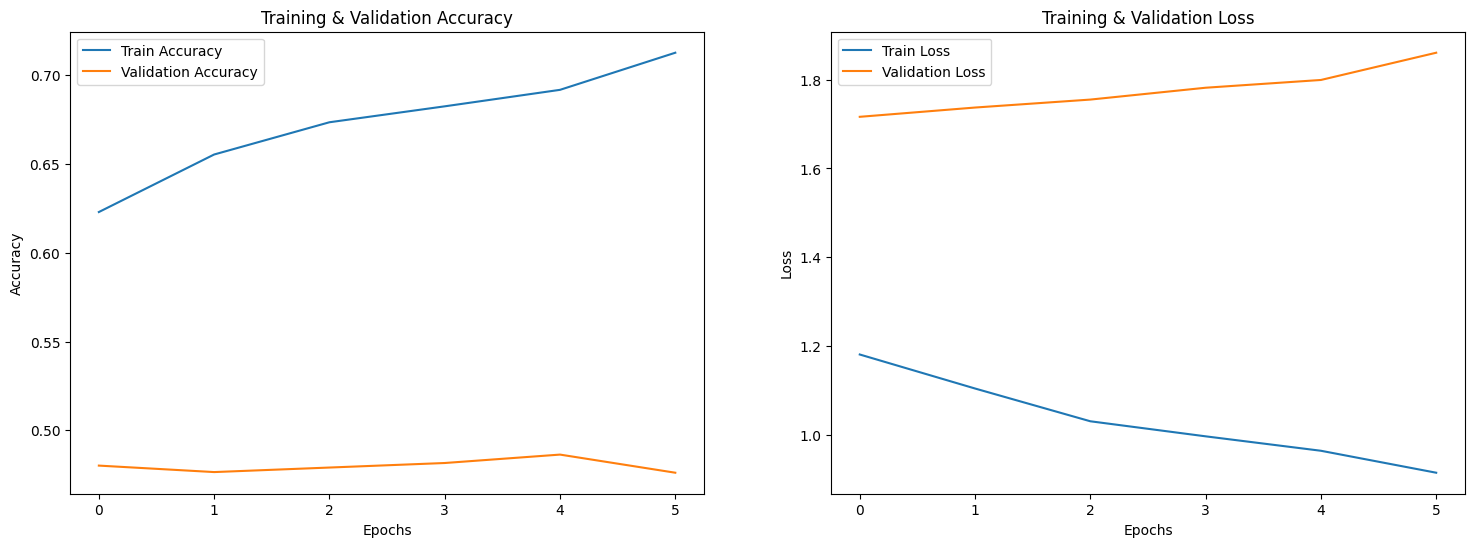

In [ ]:
plot_training_history(history)

In [ ]:
# Evaluate test accuracy
test_loss, test_acc = modal_11.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4533 - loss: 1.7981
Test Loss: 1.7391
Test Accuracy: 0.4679


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

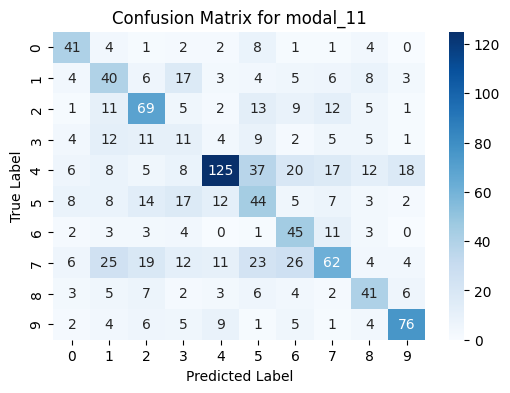

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.64      0.58        64
           1       0.33      0.42      0.37        96
           2       0.49      0.54      0.51       128
           3       0.13      0.17      0.15        64
           4       0.73      0.49      0.59       256
           5       0.30      0.37      0.33       120
           6       0.37      0.62      0.46        72
           7       0.50      0.32      0.39       192
           8       0.46      0.52      0.49        79
           9       0.68      0.67      0.68       113

    accuracy                           0.47      1184
   macro avg       0.45      0.48      0.46      1184
weighted avg       0.50      0.47      0.47      1184



In [ ]:
# Extract true labels and images from the test dataset
y_true = []
y_pred = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = modal_11.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for modal_11")
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred))


- The fine-tuned MLP model with pairwise-weighted loss improved overall accuracy slightly from 44.09% to 46.79%.
- This small increase indicates that the loss function might have helped the model to better prioritize correcting frequent misclassifications.

- Confusion was reduced for class 3 and class 9, where predictions became more accurate.
	- Out of 64 true Class 3 images, correctly classified images increased from 4 to 11
	- Out of 113 true Class 9 images, correctly classified images increased from 58 to 76

- Misclassifications increased for class 4 (overall), only 125 class 4 images were predicted correly compared to 159 before


- Missclassfication of Class 4 and Class 8 improved.
	- Previously, 25 Class 4 images were classified as Class 8
	- Afterwareds, only 12 Class 4 images were classified as Class 8


- Missclassfication of Class 9 and Class 4 improved.
	- Previously, 16 Class 9 images were classified as Class 4
	- Afterwareds, only 9 Class 9 images were classified as Class 4

- Missclassfication of Class 7 and Class 4 improved.
	- Previously, 41 Class 7 images were classified as Class 4
	- Afterwareds, only 11 Class 7 images were classified as Class 4


- However, missclassfication of Class 4 and Class 5 did not improve
	- Previously, 35 Class 4 images were classified as Class 5
	- Afterwareds, 37 Class 4 images were classified as Class 5

- The training was less stable with pairwise-weighted loss and validation loss was slightly higher, indicating trade-offs in optimization.
- The pairwise-weighted loss might have shifted the model’s focus at the expense of other class predictions.
- Even thought this approach was not overall better, it is useful when correcting specific misclassification patterns.

In [ ]:
# Clone model architecture
best_modal_q5 = tf.keras.models.clone_model(modal_11)

# Copy weights
best_modal_q5.set_weights(modal_11.get_weights())

In [ ]:
# Exponential Decay learning rate schedule
initial_learning_rate = 0.0005
decay_steps = steps_per_epoch * 5
decay_rate = 0.95

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


# Compile the model with the new loss function
best_modal_q5.compile(
    optimizer=optimizer,
    loss=pairwise_weighted_loss,  # New loss function
    metrics=['accuracy']
)

In [ ]:
# Evaluate test accuracy JUST TO CONFIRM
test_loss, test_acc = best_modal_q5.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4533 - loss: 1.7981
Test Loss: 1.7391
Test Accuracy: 0.4679


In [ ]:
# Print weights layer by layer
for layer in best_modal_q5.layers:
    print('\n')
    print(f"---------------------Layer: {layer.name}-----------------")
    for weight in layer.get_weights():
        print(weight)
    print(f"---------------------------------------------------------")



---------------------Layer: flatten_32-----------------
---------------------------------------------------------


---------------------Layer: dense_114-----------------
[[-0.09739752 -0.17714716 -0.26965484 ... -0.13667212  0.14016092
  -0.00189908]
 [-0.05912709 -0.16832542 -0.47949213 ...  0.29921564  0.12272734
   0.09089594]
 [ 0.02911826 -0.04236424 -0.79269445 ...  0.32586285  0.08834714
   0.14136313]
 ...
 [-0.09175506  0.00544444 -0.07318209 ...  0.02960741  0.19585833
   0.50811446]
 [-0.00387963  0.07290709 -0.05727367 ... -0.0098136   0.06979541
   0.46084026]
 [-0.19446118  0.32646227 -0.09223651 ...  0.11859709 -0.06470226
   0.26823533]]
[ 8.68212311e-08 -1.77630300e-05 -1.63875611e-05 -1.78907285e-05
 -3.88553381e-05  3.80610845e-06  8.17059026e-06  1.67317139e-05
  3.58279649e-05 -2.57628526e-05  1.33089804e-06  4.20600118e-05
  1.40622415e-05  1.36593026e-05  2.03528748e-06 -3.10332325e-05
  4.79278060e-06  7.01263934e-06  3.97709482e-06  1.12022999e-05
  3.504712

In [ ]:
best_modal_q5.save("Q5_pairwise_finetuned_model.h5")
files.download("Q5_pairwise_finetuned_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>